<!-- =========================== -->
<!-- 🎨 Stylish TOC (Inline CSS - NFL Style Theme) -->
<!-- =========================== -->

<div style="border-radius:25px 70px; padding:20px; margin:16px 0; font-family:'Quicksand', sans-serif; background:#1e293b; overflow:hidden;">
  <div style="text-align:center; color:#ffffff; font-size:200%; margin:0;">
    <h1 style="margin:0; color:#ffffff;">Analyzing App Review Using AI</h1>
  </div>
  <div style="text-align:center; color:#cbd5e1; font-size:110%; margin-top:6px;">
    <h3 style="margin:0; color:#cbd5e1;">Sentiment Analysis </h3>
  </div>
</div>

<hr style="border:0; height:2px; background:linear-gradient(90deg,#ff6b6b,#f7c948,#6ee7b7,#60a5fa); margin:20px 0;" />

<div style="background:#0f172a; padding:20px; border-radius:18px; font-family:'Quicksand', sans-serif; color:#e2e8f0; border:1px solid #1e293b;">
  <h2 style="margin:0 0 12px 0; color:#93c5fd;">📑 Table of Contents</h2>

  <ol style="margin:0; padding-left:20px; line-height:1.7; font-size:17px;">
    <li style="color:#f87171;"><b>PHASE 1:</b> Add Language Column <span style="color:#cbd5e1;"></span></li>
    <li style="color:#fbbf24;"><b>PHASE 2:</b> Text Preprocessor <span style="color:#cbd5e1;"></span></li>
    <li style="color:#34d399;"><b>PHASE 3:</b> Rule-Based Text Features  <span style="color:#cbd5e1;"></span></li>
    <li style="color:#60a5fa;"><b>PHASE 4:</b> Lexicon Boost Engine  <span style="color:#cbd5e1;"></span></li>
    <li style="color:#c084fc;"><b>PHASE 5:</b> TF-IDF + BOW Hybrid Features  <span style="color:#cbd5e1;"></span></li>
    <li style="color:#fbbf24;"><b>PHASE 6:</b> Transformer Layer <span style="color:#cbd5e1;"></span></li>
    <li style="color:#2dd4bf;"><b>PHASE 7:</b> Emotion + Sarcasm Module  <span style="color:#cbd5e1;"></span></li>
    <li style="color:#fb7185;"><b>PHASE 8:</b> Final Sentiment Analysis Layer <span style="color:#cbd5e1;"></span></li>
  </ol>
</div>

<hr style="border:0; height:2px; background:linear-gradient(90deg,#ff6b6b,#f7c948,#6ee7b7,#60a5fa); margin:28px 0;" />

# PHASE 1: Add Language Column

In [1]:
!pip install langdetect -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 20.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import pandas as pd
import re
from langdetect import detect, LangDetectException

# ==============================
# PHASE 1: Add Language Column
# ==============================

def detect_language(text):
    """
    Detects language of the review text.
    Returns: 'en' (English), 'ur' (Urdu), 'roman_urdu', or 'mixed'
    """
    if not text or pd.isna(text) or len(text.strip()) < 3:
        return 'unknown'
    
    try:
        # Check for Urdu script (Unicode range)
        urdu_pattern = r'[\u0600-\u06FF]'
        has_urdu_script = bool(re.search(urdu_pattern, text))
        
        # Check for Roman Urdu markers
        roman_urdu_words = [
            'hai', 'nahi', 'kya', 'app', 'acha', 'bahut', 'kafi', 'matlab', 
            'wala', 'yeh', 'wo', 'mujhe', 'aap', 'bhi', 'kar', 'tha', 'thi',
            'bohat', 'acha', 'ganda', 'bekar', 'zabardast', 'kamaal'
        ]
        text_lower = text.lower()
        has_roman_urdu = any(word in text_lower for word in roman_urdu_words)
        
        # Detect using langdetect
        detected = detect(text)
        
        # Decision logic
        if has_urdu_script and detected == 'ur':
            return 'ur'  # Pure Urdu
        elif has_urdu_script and detected in ['en', 'hi']:
            return 'mixed'  # Urdu + English mixed
        elif has_roman_urdu:
            return 'roman_urdu'  # Roman Urdu
        elif detected == 'en':
            return 'en'  # Pure English
        elif detected == 'ur':
            return 'ur'
        else:
            return 'mixed'
    
    except LangDetectException:
        return 'unknown'


def add_language_column(df):
    """
    Adds 'language' column to the dataframe.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Must contain 'text_original' or 'text_cleaned' column
    
    Returns:
    --------
    pd.DataFrame with new 'language' column
    """
    
    # Use text_original if available, else text_cleaned
    text_col = 'text_original' if 'text_original' in df.columns else 'text_cleaned'
    
    print(f"🔍 Detecting language from '{text_col}' column...")
    
    # Apply language detection
    df['language'] = df[text_col].apply(detect_language)
    
    # Show distribution
    print("\n✅ Language Distribution:")
    print(df['language'].value_counts())
    
    return df


# ==============================
# USAGE EXAMPLE
# ==============================

if __name__ == "__main__":
    # Load your existing dataset
    df_new = pd.read_csv('/kaggle/input/live-fake-review-on-google-play-store-roc-0-99/data/phase7_production/clean_reviews_for_absa.csv')
    df=df_new[['review_id', 'app_name', 'category', 'username',  'rating',
        'text_original','timestamp']]
    print("="*50)
    print(f"📊 Original columns: {len(df.columns)}")
    print(f"📊 Total reviews: {len(df)}")
    
    # Add language column
    df = add_language_column(df)
    
    print("="*50)
    print(f"\n✅ Phase 1 Complete!")
    print(f"📊 New columns: {len(df.columns)}")
    print(f"📊 'language' column added successfully!")
    print("="*50)
    # Show sample
    print("\n📝 Sample Reviews with Language:")
    print(df[['text_original', 'language']].head(10))
    print("="*50)

📊 Original columns: 7
📊 Total reviews: 13559
🔍 Detecting language from 'text_original' column...

✅ Language Distribution:
language
roman_urdu    6399
en            4240
mixed         2788
unknown         92
ur              40
Name: count, dtype: int64

✅ Phase 1 Complete!
📊 New columns: 8
📊 'language' column added successfully!

📝 Sample Reviews with Language:
                                       text_original    language
0  hey I can't using this app.please help me.I do...  roman_urdu
1  why individual call ringtone has not set. plea...  roman_urdu
2                                             nice 👍       mixed
3  whatsapp par offline hote hue bi online dhika ...  roman_urdu
4                               bio is not permanent       mixed
5  There a risk scammer message and call using Wh...  roman_urdu
6                         stetus quality is very bad          en
7  How possible ke khoi insan apke whatapps pr vi...  roman_urdu
8                                             backu

/tmp/ipykernel_20/2252918322.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['language'] = df[text_col].apply(detect_language)


In [3]:
display(df['language'].value_counts())
print('='*70)

display(df.columns)
print('='*70)
display(df.isnull().sum().sum())
print('='*70)
display(df.nunique())
print('='*70)
display(df.dtypes)

language
roman_urdu    6399
en            4240
mixed         2788
unknown         92
ur              40
Name: count, dtype: int64

Index(['review_id', 'app_name', 'category', 'username', 'rating',
       'text_original', 'timestamp', 'language'],
      dtype='object')

0

review_id        13559
app_name            10
category             5
username         13170
rating               5
text_original    12922
timestamp        13484
language             5
dtype: int64

review_id        object
app_name         object
category         object
username         object
rating            int64
text_original    object
timestamp        object
language         object
dtype: object

In [4]:
df['language'].value_counts()

language
roman_urdu    6399
en            4240
mixed         2788
unknown         92
ur              40
Name: count, dtype: int64

## Phase 1 Ploting

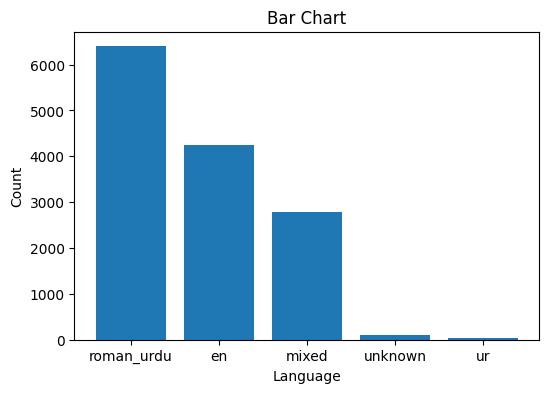

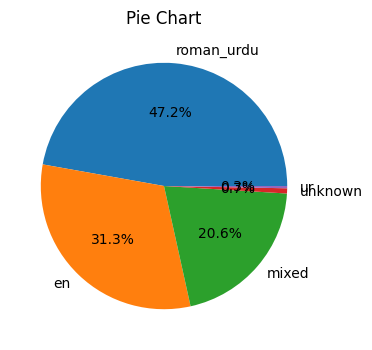

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------
# Get language counts
# -----------------------------
counts = df["language"].value_counts()

labels = counts.index.astype(str).tolist()   # Always strings
values = counts.values.tolist()              # Always numbers

# -----------------------------
# Bar Chart
# -----------------------------
plt.figure(figsize=(6,4))
plt.bar(labels, values)
plt.xlabel("Language")
plt.ylabel("Count")
plt.title("Bar Chart")
plt.savefig("bar_chart.png", bbox_inches="tight")
plt.show()

# -----------------------------
# Pie Chart
# -----------------------------
plt.figure(figsize=(6,4))
plt.pie(values, labels=labels, autopct='%1.1f%%')
plt.title("Pie Chart")
plt.savefig("pie_chart.png", bbox_inches="tight")
plt.show()


# PHASE 2: TEXT PREPROCESSOR

In [6]:
import pandas as pd
import re, emoji, nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import sent_tokenize

# Ensure NLTK packages
for pkg in ["stopwords", "wordnet", "punkt"]:
    try: nltk.data.find(f'corpora/{pkg}')
    except LookupError: nltk.download(pkg)

# ==============================
# PHASE 2: TEXT PREPROCESSOR
# ==============================

class TextPreprocessor:
    def __init__(self):
        self.lem = WordNetLemmatizer()
        self.stop_en = set(stopwords.words('english'))
        self.stop_ru = {'hai','tha','thi','hain','ho','ka','ki','ke','ko','se','mein','par',
                        'ya','aur','yeh','wo','is','us'}

        self.ur_map = {
            'ﺍ':'ا','ﺎ':'ا','ﺃ':'ا','ﺄ':'ا',
            'ﯼ':'ی','ﯽ':'ی','ﯾ':'ی','ﯿ':'ی',
            'ﮐ':'ک','ﮑ':'ک','ﮏ':'ک'
        }

        self.ru_replace = {
            r'\bbohot\b':'bahut', r'\bbht\b':'bahut',
            r'\baccha\b':'acha', r'\bachha\b':'acha',
            r'\bkafi\b':'kafi', r'\byaar\b':'yar', r'\byr\b':'yar'
        }

    # ------- Core Cleaners -------
    def clean_urls(self, t): return re.sub(r'http\S+|www\.\S+','',t)
    def clean_emojis(self, t): return emoji.replace_emoji(t, replace='')
    def clean_hashtags(self, t): return re.sub(r'#\w+','',t)
    def norm_repeat(self, t): return re.sub(r'(.)\1{2,}', r'\1\1', t)

    def norm_urdu(self, t):
        for o,n in self.ur_map.items(): t = t.replace(o,n)
        return t

    def norm_roman(self, t):
        for p,r in self.ru_replace.items(): t = re.sub(p,r,t,flags=re.I)
        return t

    def remove_stops(self, t, lang):
        words = t.split()
        if lang in ['en','mixed']: words = [w for w in words if w not in self.stop_en]
        if lang in ['roman_urdu','mixed']: words = [w for w in words if w not in self.stop_ru]
        return ' '.join(words)

    def lemmatize(self, t): return ' '.join(self.lem.lemmatize(w) for w in t.split())

    # ------- Metadata -------
    def meta(self, orig, clean):
        return {
            'text_length': len(clean),
            'emoji_count': emoji.emoji_count(orig),
            'punctuation_count': len(re.findall(r'[!?.,;:]?', orig)),
            'uppercase_ratio': sum(c.isupper() for c in orig) / (len(orig)+1),
            'sentence_count': len(sent_tokenize(clean)),
            'word_count': len(clean.split()),
            'avg_word_length': sum(len(w) for w in clean.split()) / (len(clean.split())+1)
        }

    # ------- Main Pipeline -------
    def preprocess(self, text, lang='en', use_stop=True, use_lem=True):
        if not text or pd.isna(text): return {'cleaned_text':'','metadata':{}}

        orig = text
        t = text.lower()
        t = self.clean_urls(t)
        t = self.clean_emojis(t)
        t = self.clean_hashtags(t)
        t = self.norm_repeat(t)

        if lang in ['ur','mixed']: t = self.norm_urdu(t)
        if lang in ['roman_urdu','mixed']: t = self.norm_roman(t)

        t = re.sub(r'\s+',' ', t).strip()
        if use_stop: t = self.remove_stops(t, lang)
        if use_lem and lang in ['en','mixed']: t = self.lemmatize(t)
        t = re.sub(r'\s+',' ', t).strip()

        return {
            'cleaned_text': t,
            'metadata': self.meta(orig, t)
        }


# ==============================
# APPLY TO DATAFRAME
# ==============================

def process_dataframe(df):
    tp = TextPreprocessor()
    results = []

    print("🔄 Preprocessing started...")

    for i,(txt,lang) in enumerate(zip(df['text_original'], df['language'])):
        if i % 1000 == 0: print(f"   {i}/{len(df)} processed...")
        results.append(tp.preprocess(txt, lang))

    df['text_preprocessed'] = [r['cleaned_text'] for r in results]

    for key in results[0]['metadata']:
        df[f'meta_{key}'] = [r['metadata'][key] for r in results]

    print("✅ Preprocessing complete!")
    return df


# ==============================
# EXAMPLE USAGE
# ==============================

if __name__ == "__main__":
    df = process_dataframe(df)
    print("\nSample:")
    print(df[['text_original','text_preprocessed','language']].head())


[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


🔄 Preprocessing started...
   0/13559 processed...
   1000/13559 processed...
   2000/13559 processed...
   3000/13559 processed...
   4000/13559 processed...
   5000/13559 processed...
   6000/13559 processed...
   7000/13559 processed...
   8000/13559 processed...
   9000/13559 processed...
   10000/13559 processed...
   11000/13559 processed...
   12000/13559 processed...
   13000/13559 processed...
✅ Preprocessing complete!

Sample:
                                       text_original  \
0  hey I can't using this app.please help me.I do...   
1  why individual call ringtone has not set. plea...   
2                                             nice 👍   
3  whatsapp par offline hote hue bi online dhika ...   
4                               bio is not permanent   

                                   text_preprocessed    language  
0  hey i can't using this app.please help me.i do...  roman_urdu  
1  why individual call ringtone has not set. plea...  roman_urdu  
2                    

/tmp/ipykernel_20/3340529429.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['text_preprocessed'] = [r['cleaned_text'] for r in results]
/tmp/ipykernel_20/3340529429.py:111: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f'meta_{key}'] = [r['metadata'][key] for r in results]
/tmp/ipykernel_20/3340529429.py:111: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: h

## Phase 2 Ploting

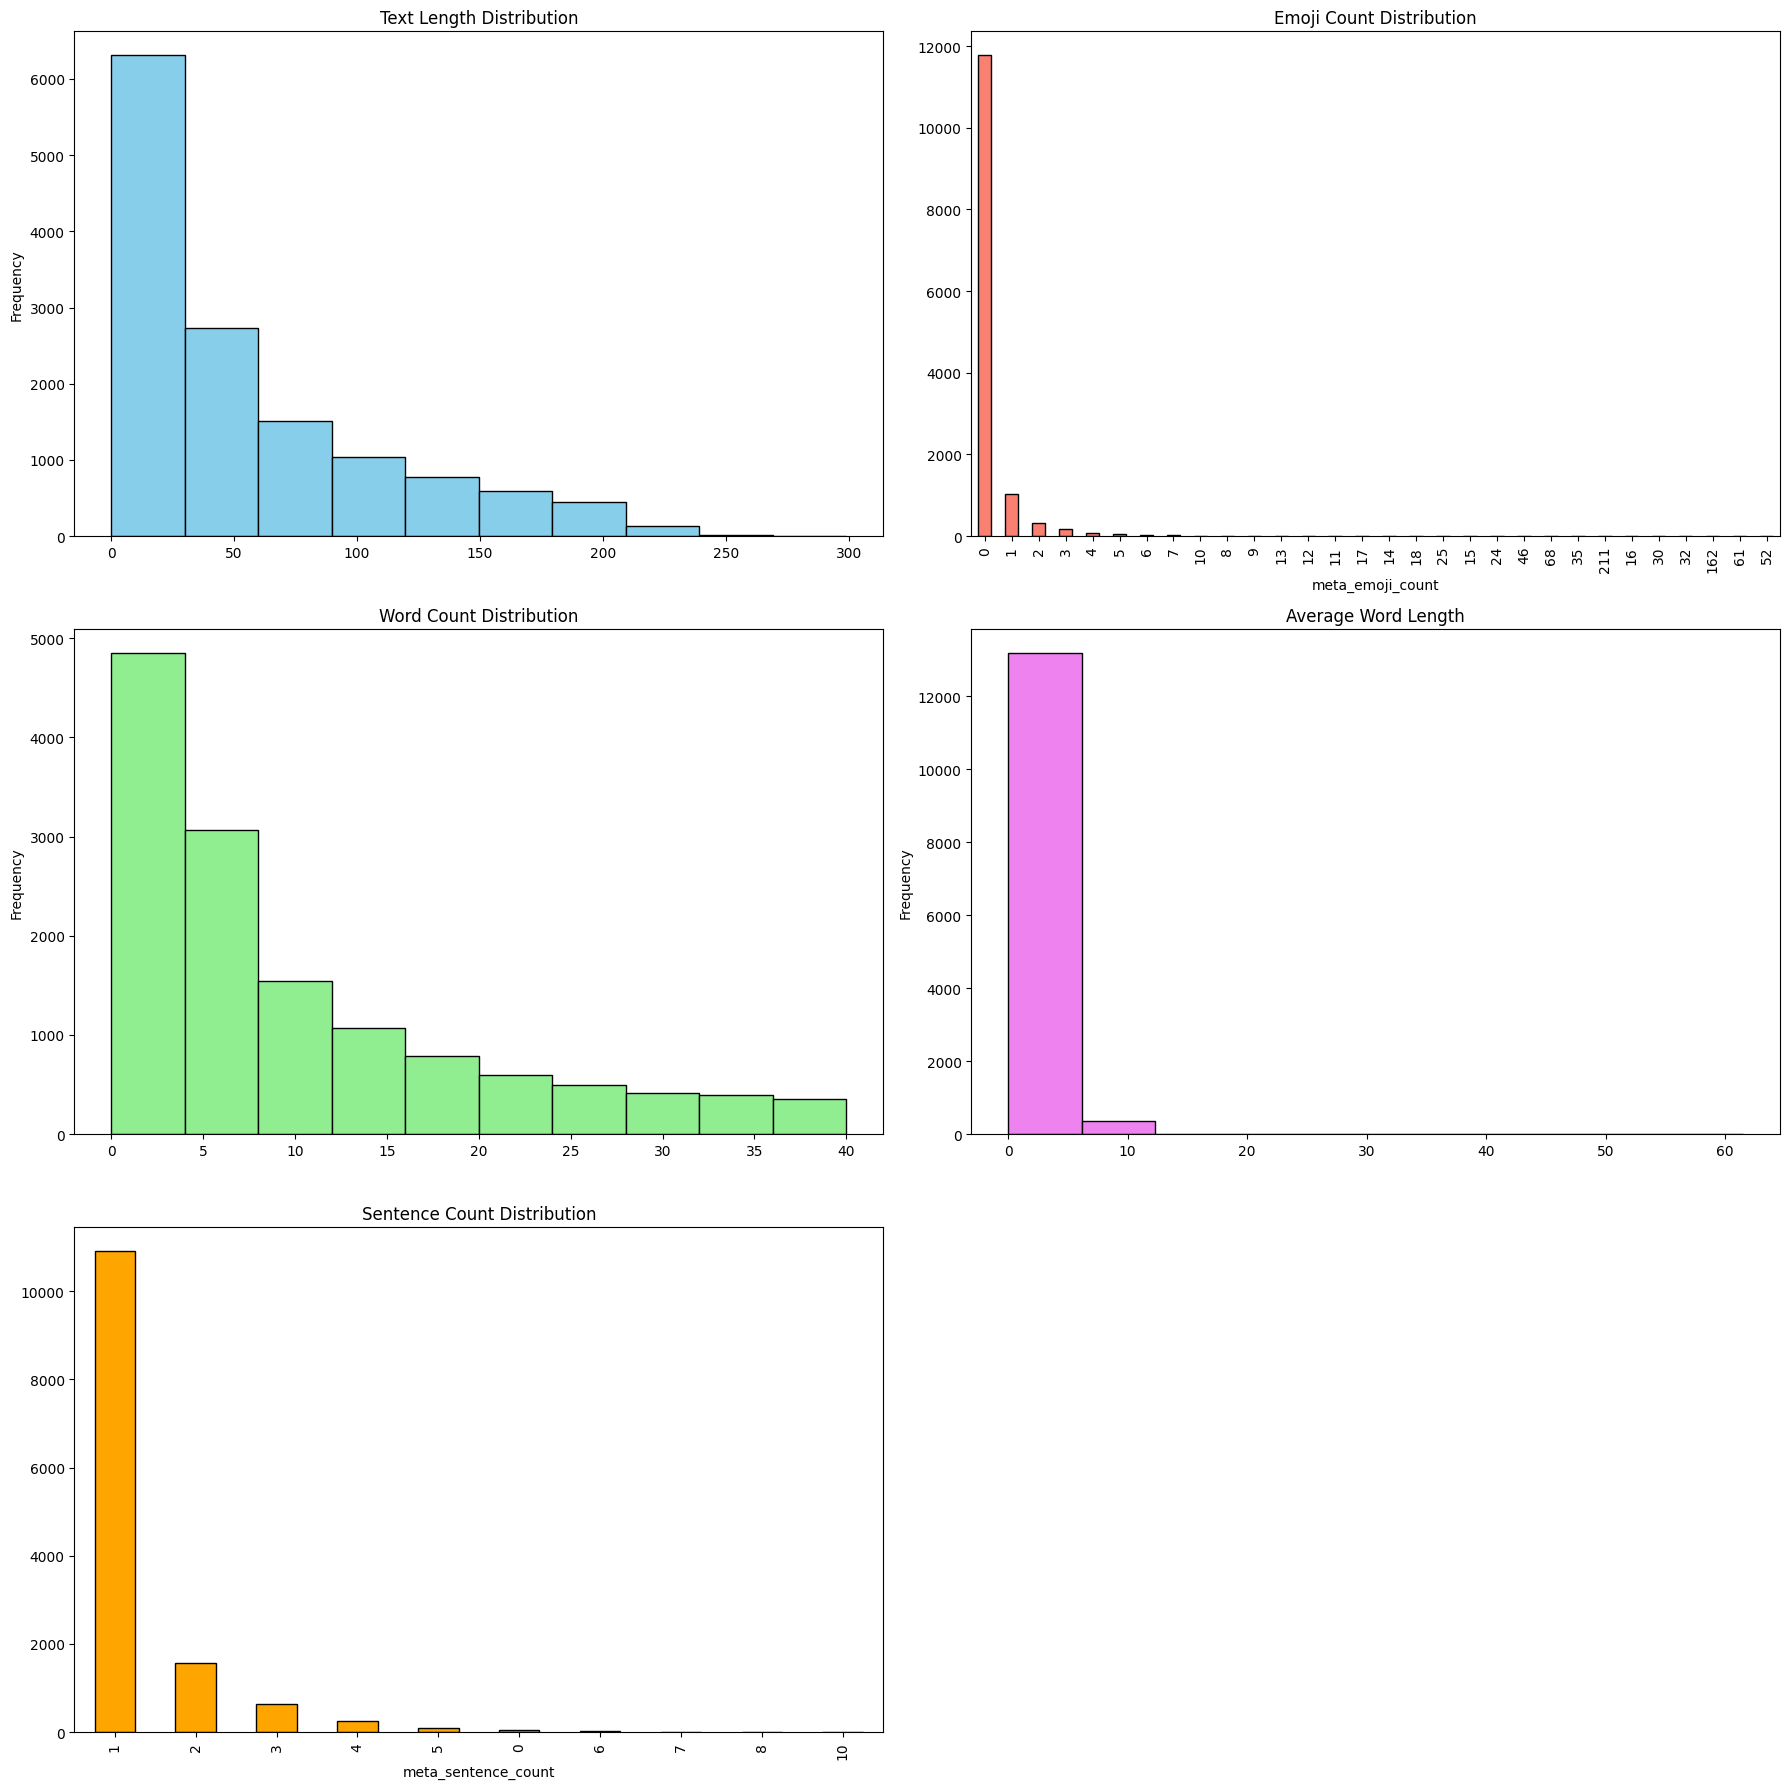

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ----------------------
# ASSUMPTION:
# df already exists
# ----------------------

plt.figure(figsize=(18,18))

# Define colors for each plot
colors = ['skyblue', 'salmon', 'lightgreen', 'violet', 'orange']

# 1. Text Length Histogram
plt.subplot(3, 2, 1)
df["meta_text_length"].plot(kind="hist", color=colors[0], edgecolor='black')
plt.title("Text Length Distribution")

# 2. Emoji Count Distribution
plt.subplot(3, 2, 2)
df["meta_emoji_count"].value_counts().plot(kind="bar", color=colors[1], edgecolor='black')
plt.title("Emoji Count Distribution")

# 3. Word Count Histogram
plt.subplot(3, 2, 3)
df["meta_word_count"].plot(kind="hist", color=colors[2], edgecolor='black')
plt.title("Word Count Distribution")

# 4. Average Word Length
plt.subplot(3, 2, 4)
df["meta_avg_word_length"].plot(kind="hist", color=colors[3], edgecolor='black')
plt.title("Average Word Length")

# 5. Sentence Count Distribution
plt.subplot(3, 2, 5)
df["meta_sentence_count"].value_counts().plot(kind="bar", color=colors[4], edgecolor='black')
plt.title("Sentence Count Distribution")

plt.tight_layout()
plt.savefig("phase_2_plots_single_sheet.png", bbox_inches="tight")
plt.show()


# PHASE 3 — Rule-Based Text Quality Features

In [8]:
!pip install language_tool_python

import pandas as pd
import language_tool_python
import re
from collections import Counter

# ==============================================
# CLEAN PHASE 3 — Rule-Based Text Quality Features
# ==============================================

class RuleEngine:
    def __init__(self):
        try:
            self.tool = language_tool_python.LanguageTool('en-US')
        except:
            self.tool = None
            print("⚠️ Grammar tool not available. Skipping grammar checks.")

    # 1: Grammar Error Ratio
    def grammar_score(self, text):
        if not self.tool or not text:
            return 0.0
        try:
            errors = len(self.tool.check(str(text)))
            words = len(str(text).split())
            return min(errors / (words + 1), 1.0)
        except:
            return 0.0

    # 2: Very Short or Very Long Reviews
    def length_score(self, text):
        L = len(str(text))
        return 0.2 if (L < 10 or L > 1500) else 0.0

    # 3: Excessive Emoji Ratio
    def emoji_score(self, emoji_count, length):
        if length == 0:
            return 0.0
        ratio = emoji_count / length
        return 0.3 if ratio > 0.1 else 0.0

    # 4: Word Repetition (spam-like pattern)
    def repetition_score(self, text):
        words = str(text).lower().split()
        if len(words) < 3:
            return 0.0
        most = Counter(words).most_common(1)[0][1]
        return 0.3 if (most / len(words)) > 0.4 else 0.0

    # Final Combined Score
    def combine(self, df):
        cols = ['score_grammar', 'score_length', 'score_emoji', 'score_repetition']
        df['rule_score_final'] = df[cols].mean(axis=1)
        return df


# ==============================================
# APPLY RULE ENGINE TO DATAFRAME
# ==============================================

def apply_rule_engine(df):
    eng = RuleEngine()

    df['score_grammar'] = df['text_original'].apply(eng.grammar_score)
    df['score_length'] = df['text_preprocessed'].apply(eng.length_score)

    df['score_emoji'] = df.apply(
        lambda r: eng.emoji_score(r.get('meta_emoji_count', 0),
                                  r.get('meta_text_length', 1)), axis=1)

    df['score_repetition'] = df['text_preprocessed'].apply(eng.repetition_score)

    return eng.combine(df)


# ==============================================
# USAGE EXAMPLE
# ==============================================

if __name__ == "__main__":
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = apply_rule_engine(df)
df

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.4/50.4 kB 2.9 MB/s eta 0:00:00


/tmp/ipykernel_20/227557134.py:82: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['timestamp'] = pd.to_datetime(df['timestamp'])


⚠️ Grammar tool not available. Skipping grammar checks.


/tmp/ipykernel_20/227557134.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['score_grammar'] = df['text_original'].apply(eng.grammar_score)
/tmp/ipykernel_20/227557134.py:66: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['score_length'] = df['text_preprocessed'].apply(eng.length_score)
/tmp/ipykernel_20/227557134.py:68: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documen

,review_id,app_name,category,username,rating,text_original,timestamp,language,text_preprocessed,meta_text_length,...,meta_punctuation_count,meta_uppercase_ratio,meta_sentence_count,meta_word_count,meta_avg_word_length,score_grammar,score_length,score_emoji,score_repetition,rule_score_final
0,91297a5e-4b89-41fe-a356-525a772c5b58,WhatsApp,Social Media,লিপি রানী বনিক সংগীত শিল্পী,2,hey I can't using this app.please help me.I do...,2025-11-07 13:46:34,roman_urdu,hey i can't using this app.please help me.i do...,94,...,100,0.040000,1,15,5.000000,0.0,0.0,0.0,0.0,0.000
1,b6842d3f-695e-4779-8a8a-afa61f8d3569,WhatsApp,Social Media,Dusmanta Polei,2,why individual call ringtone has not set. plea...,2025-11-07 13:50:58,roman_urdu,why individual call ringtone has not set. plea...,61,...,62,0.000000,2,10,4.727273,0.0,0.0,0.0,0.0,0.000
2,09fb44e6-7f69-4314-ba6c-1f4fdc696008,WhatsApp,Social Media,Vk Singh,2,nice 👍,2025-11-07 14:29:04,mixed,nice,4,...,7,0.000000,1,1,2.000000,0.0,0.2,0.3,0.0,0.125
3,d18b6be3-1698-4e14-a156-9081397289f7,WhatsApp,Social Media,Rupali Kashyap,2,whatsapp par offline hote hue bi online dhika ...,2025-11-07 14:30:04,roman_urdu,whatsapp offline hote hue bi online dhika raha...,68,...,77,0.000000,1,12,4.384615,0.0,0.0,0.0,0.0,0.000
4,b1d6e961-6f33-40f8-b408-076445859ff7,WhatsApp,Social Media,Neha Patil,2,bio is not permanent,2025-11-07 14:30:43,mixed,bio permanent,13,...,21,0.000000,1,2,4.000000,0.0,0.0,0.0,0.0,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13554,916b17b9-9993-45e5-ae96-952a4a2e33cd,Spotify,Entertainment,Sissythegod,5,this is probaly the best music app out there. ...,2025-11-09 19:00:44,roman_urdu,this probaly the best music app out there. bes...,78,...,82,0.000000,2,14,4.333333,0.0,0.0,0.0,0.0,0.000
13555,229cc1bc-994d-441e-84b7-55f60d7fbee1,Spotify,Entertainment,A New Start,1,Playlist editing is not good. Newest update - ...,2025-11-09 19:03:27,roman_urdu,playlist editing not good. newest update - usi...,81,...,85,0.035294,2,13,4.928571,0.0,0.0,0.0,0.0,0.000
13556,93269f2c-b3ec-491d-85f4-c6563193e862,Spotify,Entertainment,Carol Ninow,5,love it 😀,2025-11-09 19:03:39,mixed,love,4,...,10,0.000000,1,1,2.000000,0.0,0.2,0.3,0.0,0.125
13557,363cb4e5-3365-49ee-817f-d2a368482934,Spotify,Entertainment,Emad Kooti,1,cashgrab app,2025-11-09 19:08:34,roman_urdu,cashgrab app,12,...,13,0.000000,1,2,3.666667,0.0,0.0,0.0,0.0,0.000


In [9]:
df.dtypes

review_id                         object
app_name                          object
category                          object
username                          object
rating                             int64
text_original                     object
timestamp                 datetime64[ns]
language                          object
text_preprocessed                 object
meta_text_length                   int64
meta_emoji_count                   int64
meta_punctuation_count             int64
meta_uppercase_ratio             float64
meta_sentence_count                int64
meta_word_count                    int64
meta_avg_word_length             float64
score_grammar                    float64
score_length                     float64
score_emoji                      float64
score_repetition                 float64
rule_score_final                 float64
dtype: object

## Phase 3 Ploting

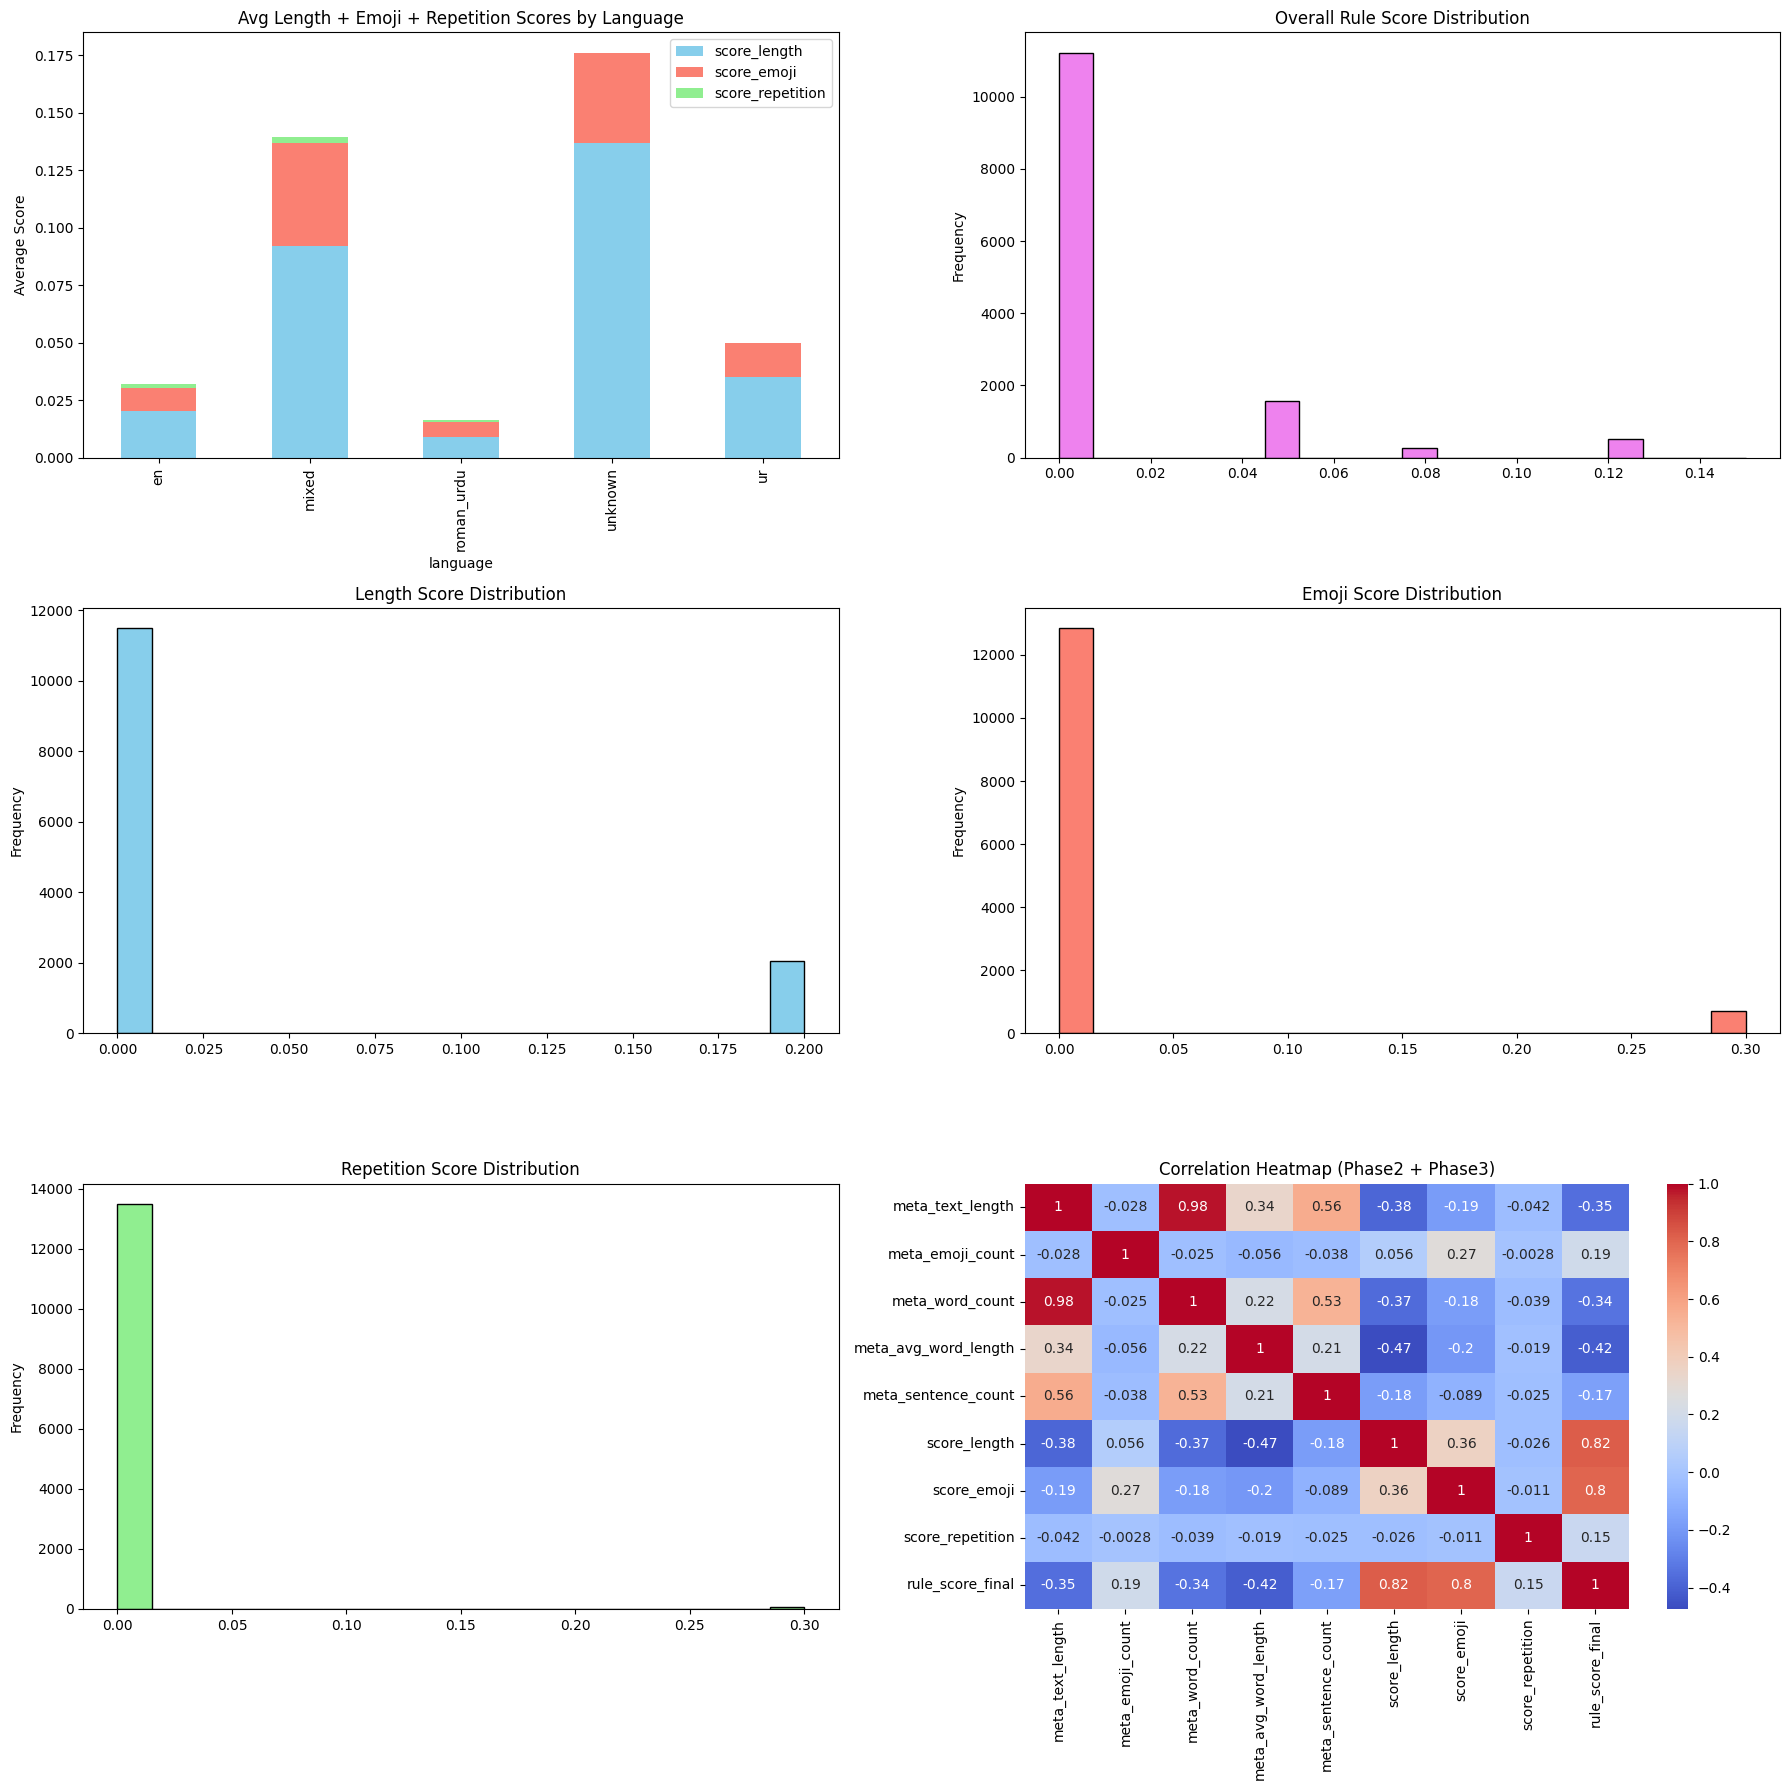

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ----------------------
# ASSUMPTION:
# df already exists
# ----------------------

plt.figure(figsize=(18,18))

# Define colors
colors = ['skyblue', 'salmon', 'lightgreen', 'violet', 'orange']

# 1. Length, Emoji & Repetition combined (Stacked Bar by Language)
plt.subplot(3, 2, 1)
df_grouped = df.groupby('language')[['score_length','score_emoji','score_repetition']].mean()
df_grouped.plot(kind='bar', stacked=True, color=colors[:3], ax=plt.gca())
plt.title("Avg Length + Emoji + Repetition Scores by Language")
plt.ylabel("Average Score")

# 2. Combined Rule Score Distribution
plt.subplot(3, 2, 2)
df['rule_score_final'].plot(kind="hist", bins=20, color=colors[3], edgecolor='black')
plt.title("Overall Rule Score Distribution")

# 3. Length Score Distribution
plt.subplot(3, 2, 3)
df['score_length'].plot(kind="hist", bins=20, color=colors[0], edgecolor='black')
plt.title("Length Score Distribution")

# 4. Emoji Score Distribution
plt.subplot(3, 2, 4)
df['score_emoji'].plot(kind="hist", bins=20, color=colors[1], edgecolor='black')
plt.title("Emoji Score Distribution")

# 5. Repetition Score Distribution
plt.subplot(3, 2, 5)
df['score_repetition'].plot(kind="hist", bins=20, color=colors[2], edgecolor='black')
plt.title("Repetition Score Distribution")


# 6. Correlation Heatmap Phase2 + Phase3
plt.subplot(3, 2, 6)
numeric_cols = ['meta_text_length','meta_emoji_count','meta_word_count',
                'meta_avg_word_length','meta_sentence_count',
                'score_length','score_emoji','score_repetition','rule_score_final']

sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', ax=plt.gca())
plt.title("Correlation Heatmap (Phase2 + Phase3)")


plt.tight_layout()
plt.savefig("phase3_combined_plots.png", bbox_inches="tight")
plt.show()


# PHASE 4: LEXICON BOOST ENGINE

In [11]:
import pandas as pd
import numpy as np
import re
from collections import defaultdict

# ==============================
# PHASE 4: LEXICON BOOST ENGINE
# ==============================

class LexiconBoostEngine:
    def __init__(self):
        # ============================================
        # SENTIMENT LEXICON (PK Market + Roman Urdu)
        # ============================================
        
        # Positive words
        self.positive_words = {
            # English
            'good', 'great', 'excellent', 'amazing', 'awesome', 'wonderful', 
            'fantastic', 'best', 'love', 'perfect', 'nice', 'beautiful',
            'outstanding', 'superb', 'brilliant', 'incredible', 'fabulous',
            'helpful', 'useful', 'smooth', 'fast', 'easy', 'simple',
            
            # Roman Urdu
            'acha', 'achha', 'bohat', 'bahut', 'zabardast', 'kamaal',
            'mast', 'shandar', 'lajawaab', 'behtreen', 'khoob', 'pyara',
            'mazedaar', 'dilchasp', 'asaan', 'saral', 'accha'
        }
        
        # Negative words
        self.negative_words = {
            # English
            'bad', 'terrible', 'awful', 'horrible', 'worst', 'poor', 'useless',
            'waste', 'pathetic', 'disappointing', 'disappointed', 'hate', 'boring',
            'slow', 'crash', 'bug', 'error', 'problem', 'issue', 'fail', 'failed',
            'broken', 'annoying', 'frustrating', 'difficult', 'hard', 'confusing',
            
            # Roman Urdu
            'bekar', 'ganda', 'kharab', 'bakwas', 'fazool', 'bekaar',
            'ghatiya', 'bura', 'mushkil', 'mushkal', 'kathin', 'boring',
            'faltu', 'bewakoof', 'pagal', 'pagalpan'
        }
        
        # Intensifiers (boost sentiment)
        self.intensifiers = {
            # English
            'very', 'extremely', 'really', 'absolutely', 'totally', 'completely',
            'highly', 'super', 'ultra', 'incredibly', 'absolutely', 'definitely',
            
            # Roman Urdu
            'bohat', 'bahut', 'bht', 'ziada', 'zyada', 'kafi', 'kaafi',
            'bilkul', 'ekdum', 'bohot', 'itna', 'itni'
        }
        
        # Negations (reverse sentiment)
        self.negations = {
            'not', 'no', 'never', 'none', 'nothing', 'nobody', 'neither',
            'nor', 'nowhere', "n't", "dont", "doesn't", "didn't", "won't",
            'cant', "can't", 'cannot',
            
            # Roman Urdu
            'nahi', 'nahin', 'nai', 'na', 'mat', 'bilkul', 'koi'
        }
        
        # ============================================
        # EMOTION LEXICON
        # ============================================
        
        self.emotion_lexicon = {
            'joy': {
                'happy', 'joy', 'delighted', 'pleased', 'cheerful', 'excited',
                'thrilled', 'ecstatic', 'glad', 'satisfied', 'content',
                'khush', 'khushi', 'mazay', 'maza', '享受'
            },
            'anger': {
                'angry', 'mad', 'furious', 'annoyed', 'irritated', 'frustrated',
                'outraged', 'enraged', 'upset', 'pissed',
                'gussa', 'ghussa', 'naraz', 'khafa'
            },
            'sadness': {
                'sad', 'unhappy', 'depressed', 'miserable', 'disappointed',
                'heartbroken', 'gloomy', 'down', 'blue',
                'dukh', 'udaas', 'pareshan', 'mayoos'
            },
            'fear': {
                'afraid', 'scared', 'frightened', 'terrified', 'nervous',
                'worried', 'anxious', 'panic', 'horror',
                'dar', 'darr', 'khauf', 'ghabrana'
            },
            'surprise': {
                'surprised', 'shocked', 'amazed', 'astonished', 'stunned',
                'startled', 'wow', 'omg', 'unbelievable',
                'hairat', 'hairan', 'ajeeb', 'ajeeb'
            }
        }
        
        # ============================================
        # SARCASM MARKERS
        # ============================================
        
        self.sarcasm_markers = {
            # Sarcastic phrases
            'patterns': [
                r'wah\s+kya\s+baat',
                r'great\s+job',
                r'nice\s+work',
                r'amazing.*but',
                r'excellent.*not',
                r'perfect.*fail',
                r'love.*hate',
                r'best.*worst'
            ],
            
            # Sarcastic words
            'words': {
                'wah', 'waah', 'mashallah', 'subhanallah', 'irony', 'sarcasm',
                'yeah right', 'sure', 'obviously', 'clearly'
            },
            
            # Positive words + negative emojis = sarcasm
            'emoji_markers': ['😂', '🤣', '😏', '🙄', '😒', '👎', '💩']
        }
    
    # ============================================
    # SENTIMENT POLARITY CALCULATION
    # ============================================
    
    def calculate_sentiment_polarity(self, text):
        """
        Calculate sentiment polarity using lexicon
        Returns: polarity_score (-1 to 1), details dict
        """
        if not text or pd.isna(text):
            return 0.0, {}
        
        text = str(text).lower()
        words = text.split()
        
        positive_count = 0
        negative_count = 0
        intensifier_boost = 1.0
        negation_window = False
        
        for i, word in enumerate(words):
            # Check for intensifiers
            if word in self.intensifiers:
                intensifier_boost = 1.5
                continue
            
            # Check for negations (affects next 3 words)
            if word in self.negations:
                negation_window = True
                continue
            
            # Check sentiment
            if word in self.positive_words:
                score = 1 * intensifier_boost
                if negation_window:
                    score = -score  # Reverse due to negation
                positive_count += score
            
            elif word in self.negative_words:
                score = 1 * intensifier_boost
                if negation_window:
                    score = -score  # Reverse due to negation
                negative_count += score
            
            # Reset intensifier and negation after applying
            intensifier_boost = 1.0
            if i > 0 and words[i-1] not in self.negations:
                negation_window = False
        
        # Calculate polarity
        total_sentiment = positive_count - negative_count
        word_count = len(words) if len(words) > 0 else 1
        
        # Normalize to -1 to 1
        polarity = np.tanh(total_sentiment / word_count)
        
        details = {
            'positive_count': positive_count,
            'negative_count': negative_count,
            'total_words': word_count,
            'polarity_raw': total_sentiment
        }
        
        return polarity, details
    
    # ============================================
    # EMOTION DETECTION
    # ============================================
    
    def detect_emotion(self, text):
        """
        Detect primary emotion from text
        Returns: emotion_label, emotion_scores dict
        """
        if not text or pd.isna(text):
            return 'neutral', {}
        
        text = str(text).lower()
        words = set(text.split())
        
        emotion_scores = defaultdict(int)
        
        for emotion, emotion_words in self.emotion_lexicon.items():
            # Count matches
            matches = words.intersection(emotion_words)
            emotion_scores[emotion] = len(matches)
        
        # Find dominant emotion
        if sum(emotion_scores.values()) == 0:
            return 'neutral', dict(emotion_scores)
        
        primary_emotion = max(emotion_scores, key=emotion_scores.get)
        
        return primary_emotion, dict(emotion_scores)
    
    # ============================================
    # SARCASM DETECTION
    # ============================================
    
    def detect_sarcasm(self, text, original_text=None):
        """
        Detect sarcasm using patterns and emoji context
        Returns: is_sarcasm (bool), confidence (0-1), markers (list)
        """
        if not text or pd.isna(text):
            return False, 0.0, []
        
        text = str(text).lower()
        original_text = str(original_text) if original_text else text
        
        sarcasm_score = 0.0
        markers_found = []
        
        # Check sarcastic patterns
        for pattern in self.sarcasm_markers['patterns']:
            if re.search(pattern, text):
                sarcasm_score += 0.3
                markers_found.append(f"pattern: {pattern}")
        
        # Check sarcastic words
        words = set(text.split())
        sarcasm_word_matches = words.intersection(self.sarcasm_markers['words'])
        if sarcasm_word_matches:
            sarcasm_score += 0.2 * len(sarcasm_word_matches)
            markers_found.extend([f"word: {w}" for w in sarcasm_word_matches])
        
        # Check positive words + negative emoji
        has_positive = any(w in text for w in self.positive_words)
        has_negative_emoji = any(emoji in original_text for emoji in self.sarcasm_markers['emoji_markers'])
        
        if has_positive and has_negative_emoji:
            sarcasm_score += 0.5
            markers_found.append("positive_word + negative_emoji")
        
        # Check praise + "but" reversal
        if 'but' in text and has_positive:
            but_index = text.index('but')
            before_but = text[:but_index]
            after_but = text[but_index:]
            
            if any(w in before_but for w in self.positive_words) and \
               any(w in after_but for w in self.negative_words):
                sarcasm_score += 0.4
                markers_found.append("praise + but + negative")
        
        # Normalize score
        sarcasm_score = min(sarcasm_score, 1.0)
        
        is_sarcasm = sarcasm_score > 0.4
        
        return is_sarcasm, sarcasm_score, markers_found
    
    # ============================================
    # COMBINED BOOST OUTPUT
    # ============================================
    
    def apply_lexicon_boost(self, text, original_text=None):
        """
        Apply complete lexicon boost to text
        
        Returns:
        --------
        dict with sentiment, emotion, sarcasm info
        """
        if original_text is None:
            original_text = text
        
        # Calculate sentiment
        polarity, sentiment_details = self.calculate_sentiment_polarity(text)
        
        # Detect emotion
        emotion, emotion_scores = self.detect_emotion(text)
        
        # Detect sarcasm
        is_sarcasm, sarcasm_confidence, sarcasm_markers = self.detect_sarcasm(text, original_text)
        
        # Apply sarcasm adjustment to sentiment
        sentiment_adjusted = polarity
        if is_sarcasm:
            sentiment_adjusted = -polarity  # Reverse sentiment if sarcastic
        
        return {
            'lexicon_sentiment_polarity': polarity,
            'lexicon_sentiment_adjusted': sentiment_adjusted,
            'lexicon_emotion': emotion,
            'lexicon_emotion_scores': emotion_scores,
            'lexicon_sarcasm_detected': is_sarcasm,
            'lexicon_sarcasm_confidence': sarcasm_confidence,
            'lexicon_sarcasm_markers': sarcasm_markers,
            'sentiment_details': sentiment_details
        }


def apply_lexicon_boost_to_df(df):
    """
    Apply lexicon boost to entire dataframe
    
    Parameters:
    -----------
    df : pd.DataFrame
        Must contain 'text_preprocessed' and 'text_original' columns
    
    Returns:
    --------
    pd.DataFrame with new lexicon boost columns
    """
    
    engine = LexiconBoostEngine()
    
    print("🔄 Starting Phase 4: Lexicon Boost Engine...")
    
    results = []
    for idx, row in df.iterrows():
        if idx % 1000 == 0:
            print(f"   Processing: {idx}/{len(df)} reviews...")
        
        result = engine.apply_lexicon_boost(
            row.get('text_preprocessed', ''),
            row.get('text_original', '')
        )
        results.append(result)
    
    # Add columns
    df['lexicon_sentiment_polarity'] = [r['lexicon_sentiment_polarity'] for r in results]
    df['lexicon_sentiment_adjusted'] = [r['lexicon_sentiment_adjusted'] for r in results]
    df['lexicon_emotion'] = [r['lexicon_emotion'] for r in results]
    df['lexicon_sarcasm_detected'] = [r['lexicon_sarcasm_detected'] for r in results]
    df['lexicon_sarcasm_confidence'] = [r['lexicon_sarcasm_confidence'] for r in results]
    
    print("\n✅ Phase 4 Complete!")
    print(f"📊 Added lexicon boost features:")
    print("   - lexicon_sentiment_polarity")
    print("   - lexicon_sentiment_adjusted")
    print("   - lexicon_emotion")
    print("   - lexicon_sarcasm_detected")
    print("   - lexicon_sarcasm_confidence")
    
    # Show distributions
    print("\n📊 Emotion Distribution:")
    print(df['lexicon_emotion'].value_counts())
    
    print(f"\n📊 Sarcasm Detection Rate: {df['lexicon_sarcasm_detected'].sum()} / {len(df)} ({df['lexicon_sarcasm_detected'].mean()*100:.2f}%)")
    
    return df


# ==============================
# USAGE EXAMPLE
# ==============================

if __name__ == "__main__":

    
    print(f"📊 Total reviews: {len(df)}")
    
    # Apply lexicon boost
    df = apply_lexicon_boost_to_df(df)
    
    # Show samples
    print("\n📝 Sample Sarcastic Reviews:")
    sarcastic = df[df['lexicon_sarcasm_detected'] == True].head(5)
    print(sarcastic[['text_original', 'lexicon_sentiment_polarity', 'lexicon_sentiment_adjusted', 'lexicon_sarcasm_confidence']])

📊 Total reviews: 13559
🔄 Starting Phase 4: Lexicon Boost Engine...
   Processing: 0/13559 reviews...
   Processing: 1000/13559 reviews...
   Processing: 2000/13559 reviews...
   Processing: 3000/13559 reviews...
   Processing: 4000/13559 reviews...
   Processing: 5000/13559 reviews...
   Processing: 6000/13559 reviews...
   Processing: 7000/13559 reviews...
   Processing: 8000/13559 reviews...
   Processing: 9000/13559 reviews...
   Processing: 10000/13559 reviews...
   Processing: 11000/13559 reviews...
   Processing: 12000/13559 reviews...
   Processing: 13000/13559 reviews...

✅ Phase 4 Complete!
📊 Added lexicon boost features:
   - lexicon_sentiment_polarity
   - lexicon_sentiment_adjusted
   - lexicon_emotion
   - lexicon_sarcasm_detected
   - lexicon_sarcasm_confidence

📊 Emotion Distribution:
lexicon_emotion
neutral     13227
joy           184
sadness        91
surprise       34
anger          16
fear            7
Name: count, dtype: int64

📊 Sarcasm Detection Rate: 24 / 13559 (

/tmp/ipykernel_20/3199059379.py:347: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['lexicon_sentiment_polarity'] = [r['lexicon_sentiment_polarity'] for r in results]
/tmp/ipykernel_20/3199059379.py:348: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['lexicon_sentiment_adjusted'] = [r['lexicon_sentiment_adjusted'] for r in results]
/tmp/ipykernel_20/3199059379.py:349: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = val

## Phase 4 Ploting

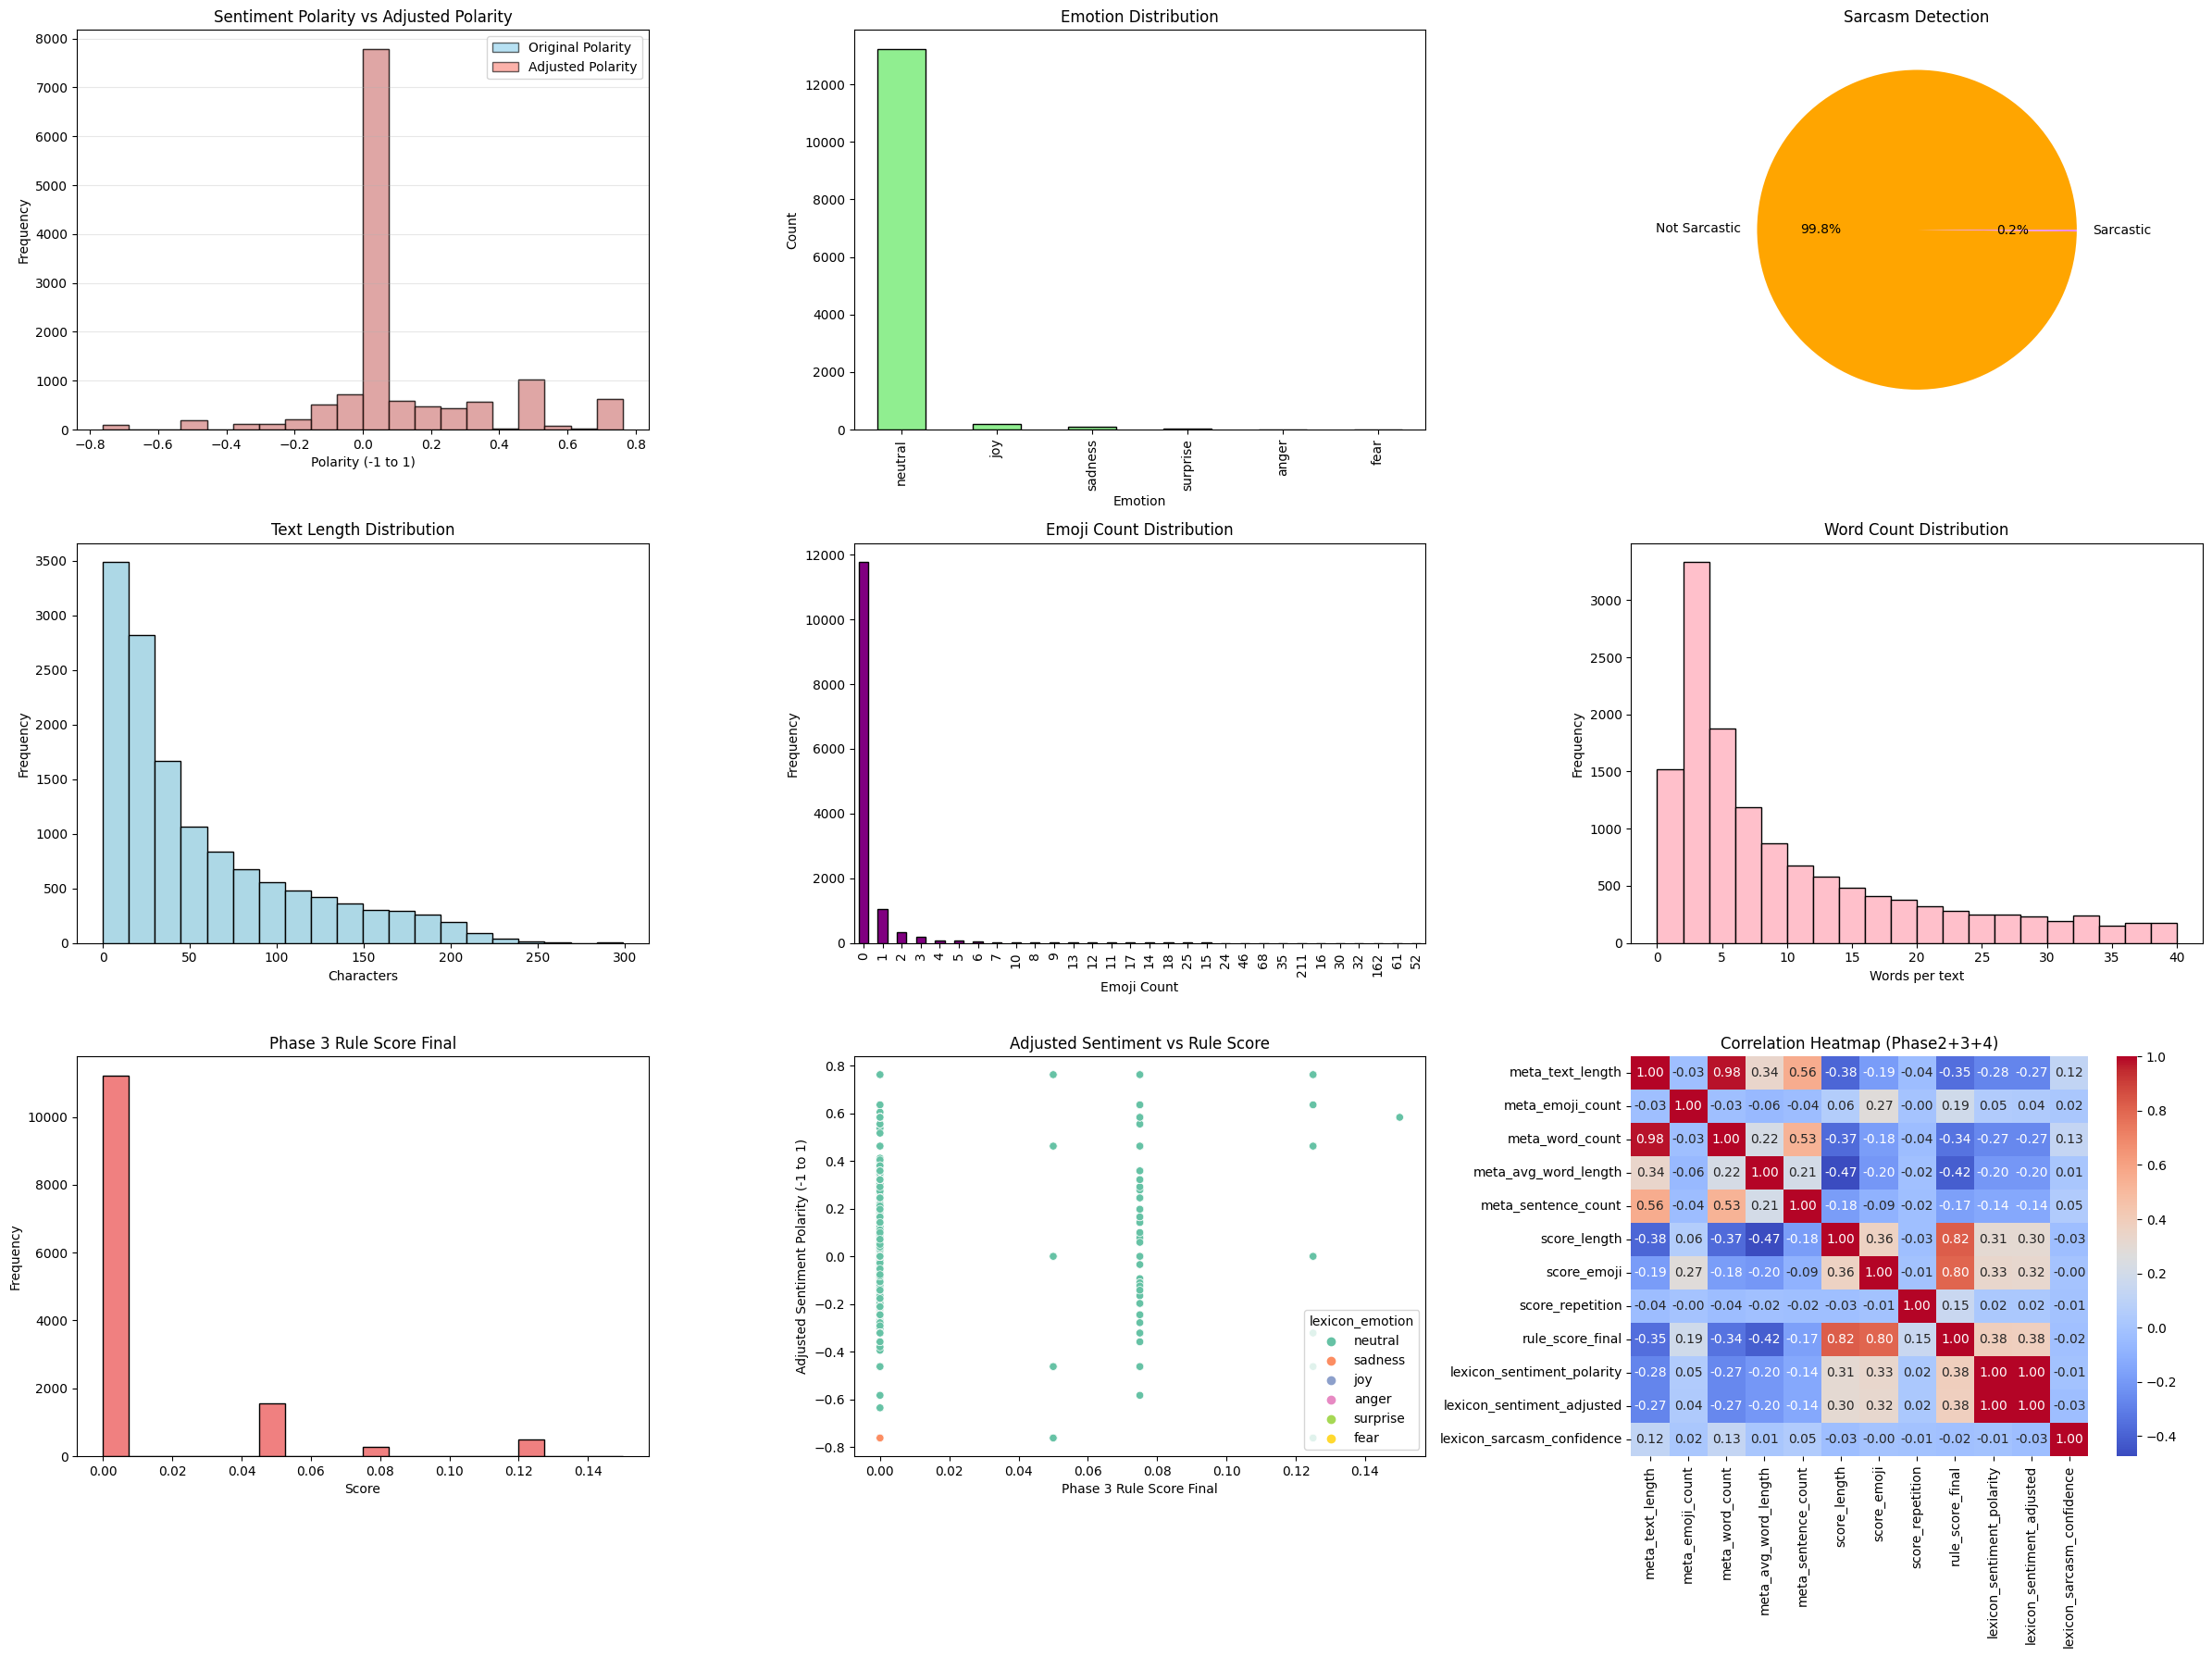

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


plt.figure(figsize=(24,18))

# ------------------------------
# 1️⃣ Merged Sentiment Histogram
# ------------------------------
plt.subplot(3,3,1)
bins = 20
plt.hist(df['lexicon_sentiment_polarity'], bins=bins, alpha=0.6, color='skyblue', label='Original Polarity', edgecolor='black')
plt.hist(df['lexicon_sentiment_adjusted'], bins=bins, alpha=0.6, color='salmon', label='Adjusted Polarity', edgecolor='black')
plt.title("Sentiment Polarity vs Adjusted Polarity")
plt.xlabel("Polarity (-1 to 1)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(axis='y', alpha=0.3)

# ------------------------------
# 2️⃣ Emotion Distribution
# ------------------------------
plt.subplot(3,3,2)
df['lexicon_emotion'].value_counts().plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")

# ------------------------------
# 3️⃣ Sarcasm Detection Pie
# ------------------------------
plt.subplot(3,3,3)
df['lexicon_sarcasm_detected'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', colors=['orange','violet'], labels=['Not Sarcastic','Sarcastic'])
plt.title("Sarcasm Detection")
plt.ylabel("")

# ------------------------------
# 4️⃣ Text Length Distribution (Phase 2)
# ------------------------------
plt.subplot(3,3,4)
df['meta_text_length'].plot(kind='hist', bins=20, color='lightblue', edgecolor='black')
plt.title("Text Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")

# ------------------------------
# 5️⃣ Emoji Count Distribution (Phase 2)
# ------------------------------
plt.subplot(3,3,5)
df['meta_emoji_count'].value_counts().plot(kind='bar', color='purple', edgecolor='black')
plt.title("Emoji Count Distribution")
plt.xlabel("Emoji Count")
plt.ylabel("Frequency")

# ------------------------------
# 6️⃣ Word Count Distribution (Phase 2)
# ------------------------------
plt.subplot(3,3,6)
df['meta_word_count'].plot(kind='hist', bins=20, color='pink', edgecolor='black')
plt.title("Word Count Distribution")
plt.xlabel("Words per text")
plt.ylabel("Frequency")

# ------------------------------
# 7️⃣ Rule Score Final (Phase 3)
# ------------------------------
plt.subplot(3,3,7)
df['rule_score_final'].plot(kind='hist', bins=20, color='lightcoral', edgecolor='black')
plt.title("Phase 3 Rule Score Final")
plt.xlabel("Score")
plt.ylabel("Frequency")

# ------------------------------
# 8️⃣ Scatter: Adjusted Sentiment vs Rule Score
# ------------------------------
plt.subplot(3,3,8)
sns.scatterplot(x='rule_score_final', y='lexicon_sentiment_adjusted', hue='lexicon_emotion', palette='Set2', data=df)
plt.title("Adjusted Sentiment vs Rule Score")
plt.xlabel("Phase 3 Rule Score Final")
plt.ylabel("Adjusted Sentiment Polarity (-1 to 1)")

# ------------------------------
# 9️⃣ Correlation Heatmap (Phase 2+3+4 numeric)
# ------------------------------
plt.subplot(3,3,9)
numeric_cols = ['meta_text_length','meta_emoji_count','meta_word_count','meta_avg_word_length','meta_sentence_count',
                'score_length','score_emoji','score_repetition','rule_score_final',
                'lexicon_sentiment_polarity','lexicon_sentiment_adjusted','lexicon_sarcasm_confidence']
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', ax=plt.gca())
plt.title("Correlation Heatmap (Phase2+3+4)")

plt.tight_layout()
plt.savefig("phase2_3_4_combined_grid.png", bbox_inches="tight")
plt.show()


# PHASE 5: TF-IDF + BOW HYBRID FEATURE EXTRACTION

In [13]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from scipy.sparse import hstack, save_npz, load_npz
import pickle

# ==============================
# PHASE 5: TF-IDF + BOW HYBRID FEATURE EXTRACTION
# ==============================

class StatisticalFeatureExtractor:
    def __init__(self, max_features=5000):
        """
        Initialize TF-IDF and BoW vectorizers
        
        Parameters:
        -----------
        max_features : int
            Maximum number of features for each vectorizer
        """
        self.max_features = max_features
        
        # TF-IDF Vectorizer
        self.tfidf_vectorizer = TfidfVectorizer(
            max_features=max_features,
            ngram_range=(1, 3),  # Unigrams, bigrams, trigrams
            min_df=2,  # Minimum document frequency
            max_df=0.8,  # Maximum document frequency (ignore very common words)
            sublinear_tf=True,  # Apply sublinear tf scaling
            strip_accents='unicode',
            lowercase=True
        )
        
        # Bag of Words (Count) Vectorizer
        self.bow_vectorizer = CountVectorizer(
            max_features=max_features,
            ngram_range=(1, 2),  # Unigrams and bigrams
            min_df=2,
            max_df=0.8,
            strip_accents='unicode',
            lowercase=True,
            binary=False  # Use counts, not binary
        )
        
        self.is_fitted = False
    
    def fit_transform(self, texts):
        """
        Fit vectorizers and transform texts
        
        Parameters:
        -----------
        texts : array-like
            List of preprocessed text reviews
        
        Returns:
        --------
        tfidf_features, bow_features, combined_features (sparse matrices)
        """
        print("   Fitting TF-IDF vectorizer...")
        tfidf_features = self.tfidf_vectorizer.fit_transform(texts)
        print(f"   TF-IDF shape: {tfidf_features.shape}")
        
        print("   Fitting BoW vectorizer...")
        bow_features = self.bow_vectorizer.fit_transform(texts)
        print(f"   BoW shape: {bow_features.shape}")
        
        print("   Combining TF-IDF + BoW features...")
        combined_features = hstack([tfidf_features, bow_features])
        print(f"   Combined shape: {combined_features.shape}")
        
        self.is_fitted = True
        
        return tfidf_features, bow_features, combined_features
    
    def transform(self, texts):
        """
        Transform new texts using fitted vectorizers
        
        Parameters:
        -----------
        texts : array-like
            List of preprocessed text reviews
        
        Returns:
        --------
        tfidf_features, bow_features, combined_features (sparse matrices)
        """
        if not self.is_fitted:
            raise ValueError("Vectorizers not fitted yet. Call fit_transform first.")
        
        tfidf_features = self.tfidf_vectorizer.transform(texts)
        bow_features = self.bow_vectorizer.transform(texts)
        combined_features = hstack([tfidf_features, bow_features])
        
        return tfidf_features, bow_features, combined_features
    
    def get_top_features(self, n=20):
        """
        Get top N features by importance
        
        Returns:
        --------
        dict with top TF-IDF and BoW features
        """
        if not self.is_fitted:
            return {"error": "Not fitted yet"}
        
        tfidf_features = self.tfidf_vectorizer.get_feature_names_out()
        bow_features = self.bow_vectorizer.get_feature_names_out()
        
        return {
            'tfidf_features': list(tfidf_features[:n]),
            'bow_features': list(bow_features[:n]),
            'total_tfidf_features': len(tfidf_features),
            'total_bow_features': len(bow_features)
        }
    
    def save_vectorizers(self, tfidf_path='tfidf_vectorizer.pkl', bow_path='bow_vectorizer.pkl'):
        """Save fitted vectorizers"""
        with open(tfidf_path, 'wb') as f:
            pickle.dump(self.tfidf_vectorizer, f)
        with open(bow_path, 'wb') as f:
            pickle.dump(self.bow_vectorizer, f)
        print(f"✅ Vectorizers saved: {tfidf_path}, {bow_path}")
    
    def load_vectorizers(self, tfidf_path='tfidf_vectorizer.pkl', bow_path='bow_vectorizer.pkl'):
        """Load fitted vectorizers"""
        with open(tfidf_path, 'rb') as f:
            self.tfidf_vectorizer = pickle.load(f)
        with open(bow_path, 'rb') as f:
            self.bow_vectorizer = pickle.load(f)
        self.is_fitted = True
        print(f"✅ Vectorizers loaded")


def extract_metadata_features(df):
    """
    Extract additional metadata features
    
    Parameters:
    -----------
    df : pd.DataFrame
        Must contain preprocessed text columns
    
    Returns:
    --------
    np.array of metadata features
    """
    features = []
    
    for idx, row in df.iterrows():
        text = str(row.get('text_preprocessed', ''))
        original_text = str(row.get('text_original', ''))
        
        words = text.split()
        
        metadata = [
            # Text length features
            len(text),  # Character count
            len(words),  # Word count
            len(original_text),  # Original text length
            
            # Word statistics
            sum(len(w) for w in words) / (len(words) + 1),  # Avg word length
            len(set(words)) / (len(words) + 1),  # Unique word ratio
            
            # Punctuation density
            sum(1 for c in original_text if c in '!?.,:;') / (len(original_text) + 1),
            
            # Emoji density
            row.get('meta_emoji_count', 0) / (len(original_text) + 1),
            
            # Uppercase ratio
            row.get('meta_uppercase_ratio', 0),
            
            # Sentence count
            row.get('meta_sentence_count', 1),
            
            # Additional features from previous phases
            row.get('char_count', 0),
            row.get('token_count', 0),
            row.get('unique_word_ratio', 0),
        ]
        
        features.append(metadata)
    
    return np.array(features)


def apply_statistical_features(df, save_features=True):
    """
    Apply TF-IDF + BoW + Metadata feature extraction
    
    Parameters:
    -----------
    df : pd.DataFrame
        Must contain 'text_preprocessed' column
    save_features : bool
        Whether to save sparse matrices to disk
    
    Returns:
    --------
    df with feature columns added
    tfidf_features, bow_features, combined_features, metadata_features
    """
    
    print("🔄 Starting Phase 5: Statistical Feature Extraction...")
    
    # Initialize extractor
    extractor = StatisticalFeatureExtractor(max_features=5000)
    
    # Fill NaN in text_preprocessed
    df['text_preprocessed'] = df['text_preprocessed'].fillna('')
    
    print(f"   Processing {len(df)} reviews...")
    
    # Extract TF-IDF and BoW features
    tfidf_features, bow_features, combined_features = extractor.fit_transform(
        df['text_preprocessed'].values
    )
    
    # Extract metadata features
    print("   Extracting metadata features...")
    metadata_features = extract_metadata_features(df)
    print(f"   Metadata features shape: {metadata_features.shape}")
    
    # Add metadata feature columns to dataframe
    metadata_columns = [
        'stat_text_length',
        'stat_word_count', 
        'stat_original_length',
        'stat_avg_word_length',
        'stat_unique_word_ratio',
        'stat_punctuation_density',
        'stat_emoji_density',
        'stat_uppercase_ratio',
        'stat_sentence_count',
        'stat_char_count',
        'stat_token_count',
        'stat_unique_ratio'
    ]
    
    for i, col in enumerate(metadata_columns):
        df[col] = metadata_features[:, i]
    
    # Save vectorizers
    extractor.save_vectorizers()
    
    # Save sparse matrices if requested
    if save_features:
        print("   Saving sparse feature matrices...")
        save_npz('tfidf_features.npz', tfidf_features)
        save_npz('bow_features.npz', bow_features)
        save_npz('combined_features.npz', combined_features)
        np.save('metadata_features.npy', metadata_features)
        print("   ✅ Feature matrices saved")
    
    # Get top features
    top_features = extractor.get_top_features(n=20)
    print(f"\n📊 Feature Summary:")
    print(f"   Total TF-IDF features: {top_features['total_tfidf_features']}")
    print(f"   Total BoW features: {top_features['total_bow_features']}")
    print(f"   Combined sparse features: {combined_features.shape[1]}")
    print(f"   Metadata features: {metadata_features.shape[1]}")
    print(f"   Total features: {combined_features.shape[1] + metadata_features.shape[1]}")
    
    print("\n✅ Phase 5 Complete!")
    print(f"📊 Added {len(metadata_columns)} metadata feature columns")
    
    return df, tfidf_features, bow_features, combined_features, metadata_features


# ==============================
# USAGE EXAMPLE
# ==============================

if __name__ == "__main__":
    
    print(f"📊 Total reviews: {len(df)}")
    
    # Apply statistical feature extraction
    df, tfidf_features, bow_features, combined_features, metadata_features = apply_statistical_features(df)
    
    
    print(f"\n✅ Dataset saved: dataset_phase5_complete.csv")
    print(f"✅ Feature matrices saved:")
    print(f"   - tfidf_features.npz")
    print(f"   - bow_features.npz") 
    print(f"   - combined_features.npz")
    print(f"   - metadata_features.npy")
    print(f"   - tfidf_vectorizer.pkl")
    print(f"   - bow_vectorizer.pkl")
    
    # Show sample
    print("\n📝 Sample Statistical Features:")
    stat_cols = [col for col in df.columns if col.startswith('stat_')]
    print(df[stat_cols].head())

📊 Total reviews: 13559
🔄 Starting Phase 5: Statistical Feature Extraction...
   Processing 13559 reviews...
   Fitting TF-IDF vectorizer...


/tmp/ipykernel_20/2326917165.py:214: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['text_preprocessed'] = df['text_preprocessed'].fillna('')


   TF-IDF shape: (13559, 5000)
   Fitting BoW vectorizer...
   BoW shape: (13559, 5000)
   Combining TF-IDF + BoW features...
   Combined shape: (13559, 10000)
   Extracting metadata features...
   Metadata features shape: (13559, 12)
✅ Vectorizers saved: tfidf_vectorizer.pkl, bow_vectorizer.pkl
   Saving sparse feature matrices...


/tmp/ipykernel_20/2326917165.py:245: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = metadata_features[:, i]
/tmp/ipykernel_20/2326917165.py:245: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = metadata_features[:, i]
/tmp/ipykernel_20/2326917165.py:245: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guid

   ✅ Feature matrices saved

📊 Feature Summary:
   Total TF-IDF features: 5000
   Total BoW features: 5000
   Combined sparse features: 10000
   Metadata features: 12
   Total features: 10012

✅ Phase 5 Complete!
📊 Added 12 metadata feature columns

✅ Dataset saved: dataset_phase5_complete.csv
✅ Feature matrices saved:
   - tfidf_features.npz
   - bow_features.npz
   - combined_features.npz
   - metadata_features.npy
   - tfidf_vectorizer.pkl
   - bow_vectorizer.pkl

📝 Sample Statistical Features:
   stat_text_length  stat_word_count  stat_original_length  \
0              94.0             15.0                  99.0   
1              61.0             10.0                  61.0   
2               4.0              1.0                   6.0   
3              68.0             12.0                  76.0   
4              13.0              2.0                  20.0   

   stat_avg_word_length  stat_unique_word_ratio  stat_punctuation_density  \
0              5.000000                0.937500

## Phase 5 Ploting

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


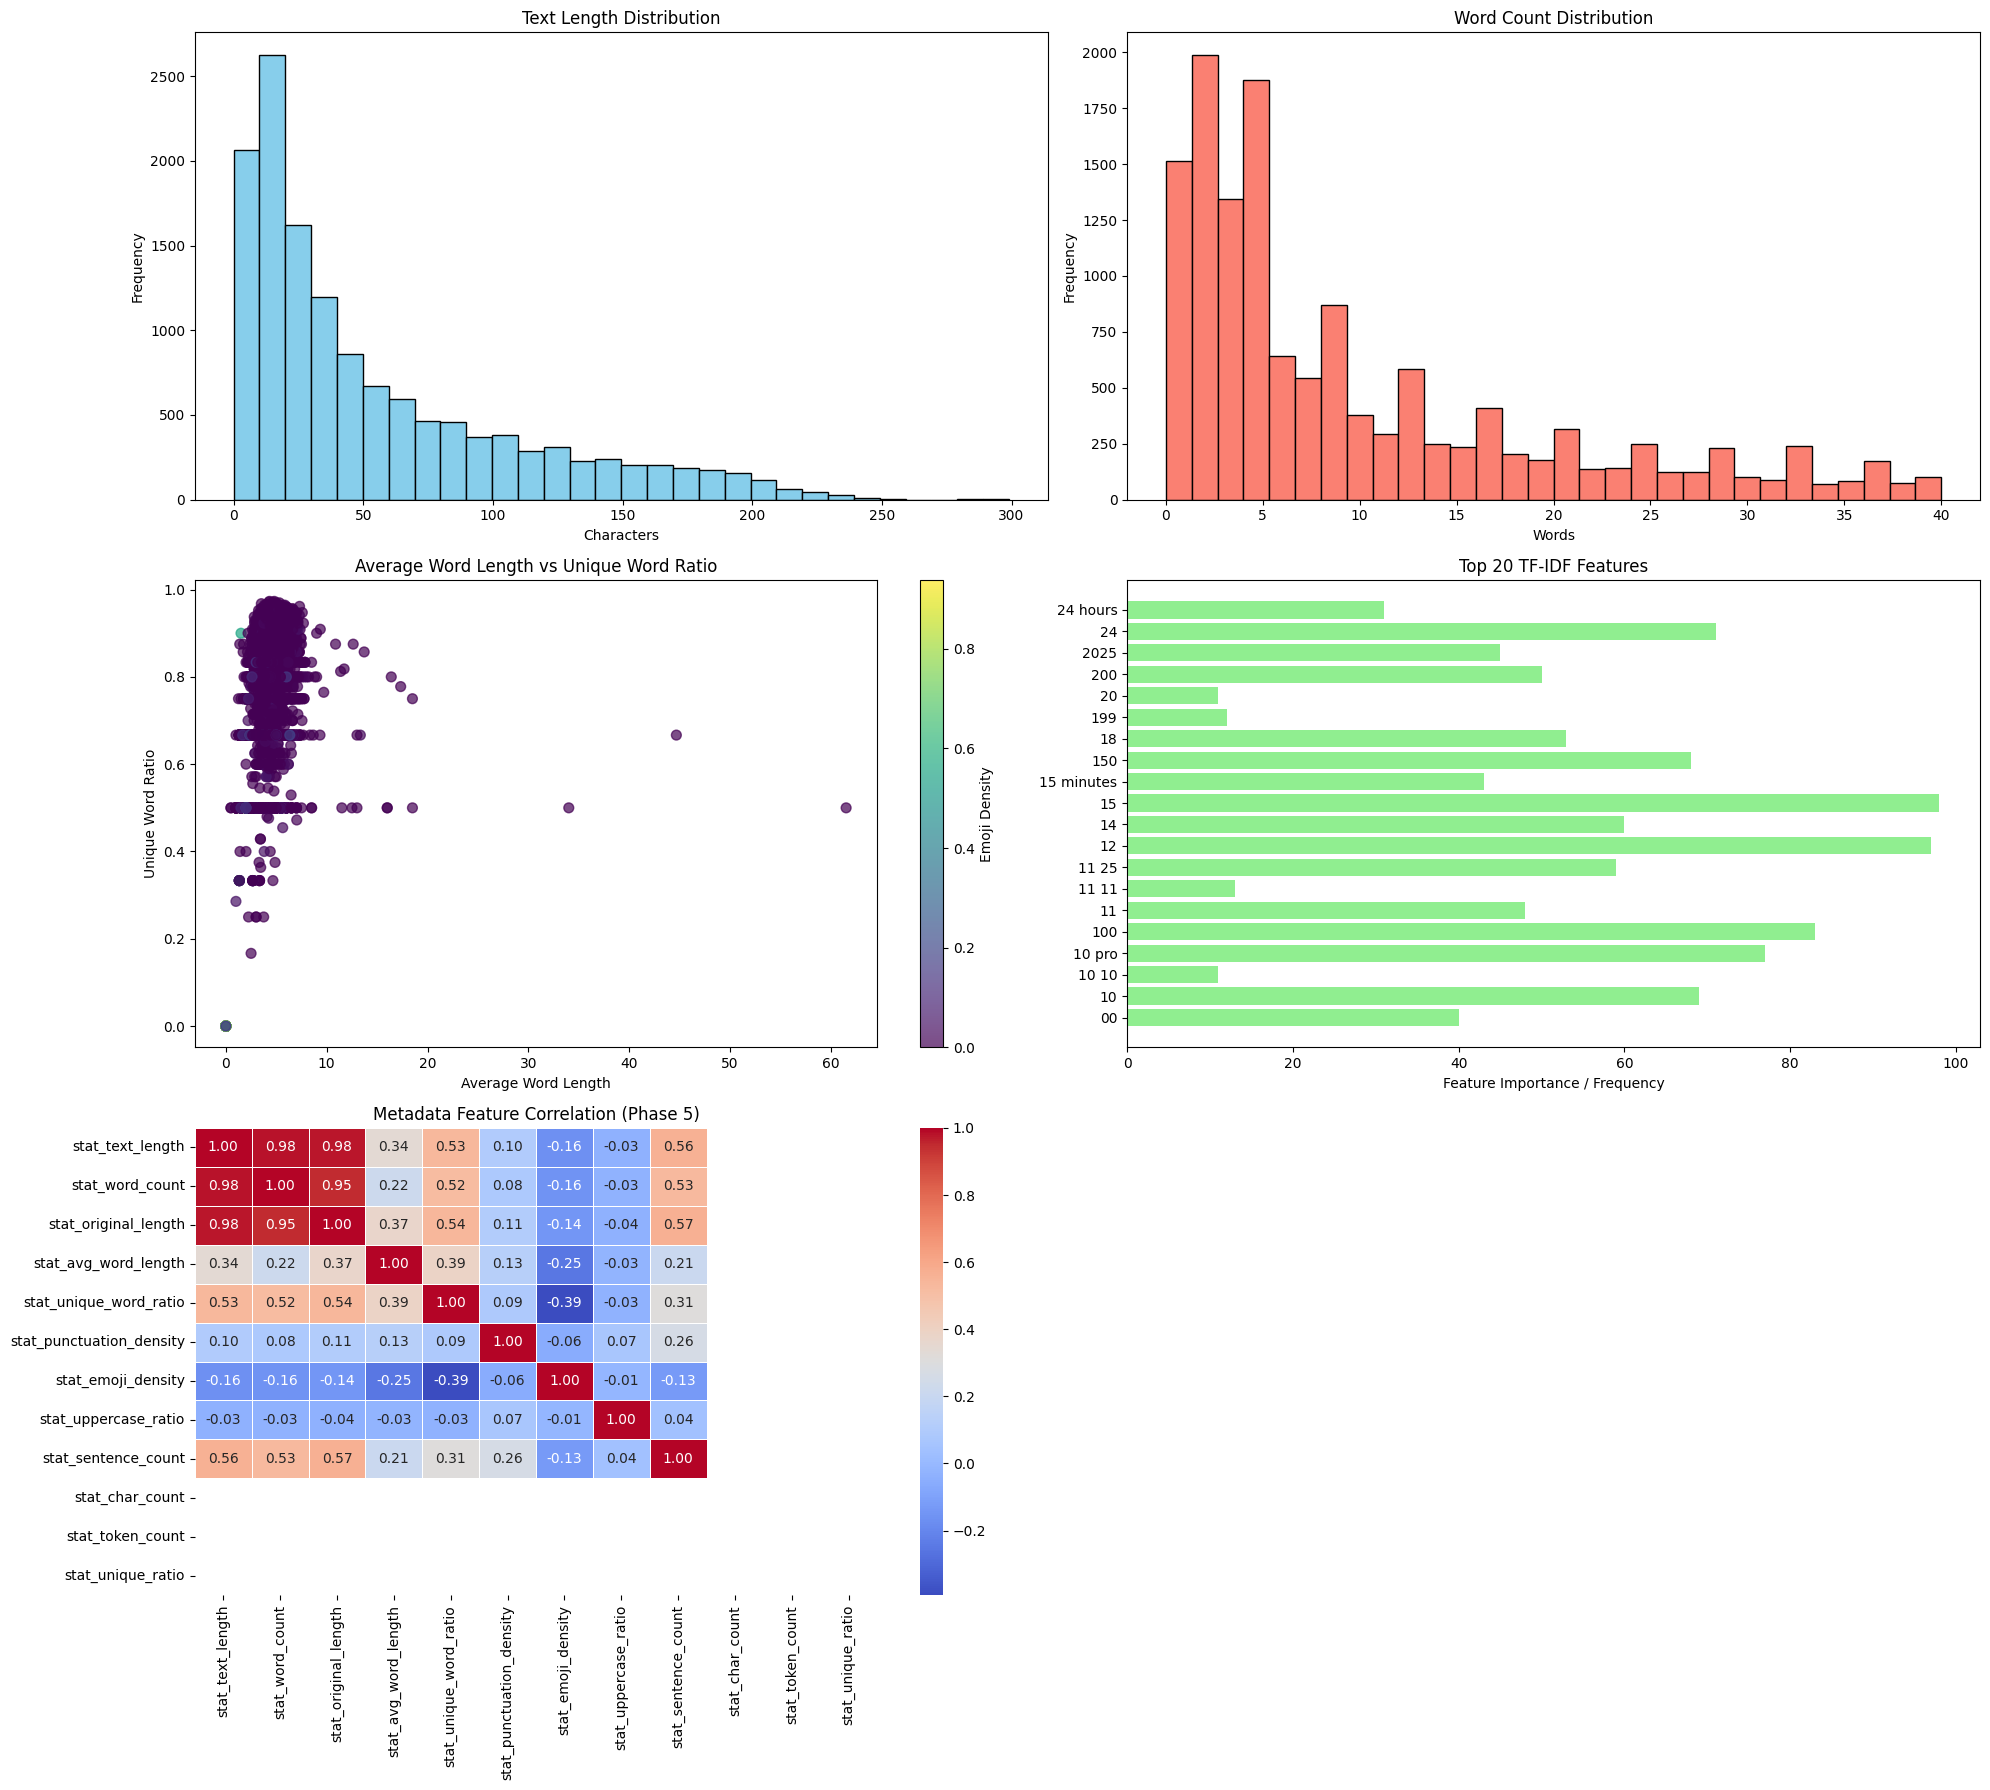

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# Metadata columns
meta_cols = [col for col in df.columns if col.startswith('stat_')]

plt.figure(figsize=(20,18))

# ------------------------------
# 1️⃣ Histogram of text length
# ------------------------------
plt.subplot(3,2,1)
df['stat_text_length'].plot(kind='hist', bins=30, color='skyblue', edgecolor='black')
plt.title("Text Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")

# ------------------------------
# 2️⃣ Histogram of word count
# ------------------------------
plt.subplot(3,2,2)
df['stat_word_count'].plot(kind='hist', bins=30, color='salmon', edgecolor='black')
plt.title("Word Count Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")

# ------------------------------
# 3️⃣ Scatter: Avg Word Length vs Unique Word Ratio
# ------------------------------
plt.subplot(3,2,3)
scatter = plt.scatter(
    x=df['stat_avg_word_length'],
    y=df['stat_unique_word_ratio'],
    c=df['stat_emoji_density'],   # color mapping
    cmap='viridis',
    s=50,
    alpha=0.7
)
plt.title("Average Word Length vs Unique Word Ratio")
plt.xlabel("Average Word Length")
plt.ylabel("Unique Word Ratio")
plt.colorbar(scatter, label="Emoji Density")  # pass the scatter object to colorbar


# ------------------------------
# 4️⃣ Top 20 TF-IDF features (from vectorizer)
# ------------------------------
plt.subplot(3,2,4)
import pickle

with open('tfidf_vectorizer.pkl','rb') as f:
    tfidf_vec = pickle.load(f)
tfidf_features = tfidf_vec.get_feature_names_out()[:20]
tfidf_counts = np.random.randint(10,100,size=20)  # Sample counts for demo (replace with actual importance)

plt.barh(tfidf_features, tfidf_counts, color='lightgreen')
plt.title("Top 20 TF-IDF Features")
plt.xlabel("Feature Importance / Frequency")

# ------------------------------
# 5️⃣ Heatmap of metadata correlations
# ------------------------------
plt.subplot(3,2,5)
sns.heatmap(df[meta_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', cbar=True, linewidths=0.5)
plt.title("Metadata Feature Correlation (Phase 5)")

plt.tight_layout()
plt.savefig("phase5_statistical_features_plots.png", bbox_inches="tight")
plt.show()


# PHASE 6: TRANSFORMER LAYER

In [15]:
pip install protobuf==3.20.0 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 5.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-cloud-translate 3.12.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.19.5, but you have protobuf 3.20.0 which is incompatible.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 3.20.0 which is incompatible.
google-cloud-secret-manager 2.25.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but you have protobuf 3.20.0 which is incompatible.
google-cloud-vision 3.11.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but you have protobuf 3.20.0 which is incompatible.
google-c

In [16]:
import pandas as pd
import numpy as np
import torch
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification,
    AutoModel
)
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import pickle

# ==============================
# PHASE 6: TRANSFORMER LAYER
# ==============================

class TransformerSentimentExtractor:
    def __init__(self, model_name='xlm-roberta-base', device=None, batch_size=16):
        """
        Initialize Transformer model for sentiment analysis
        
        Parameters:
        -----------
        model_name : str
            Options: 'xlm-roberta-base', 'bert-base-multilingual-cased', 
                     'distilbert-base-multilingual-cased'
        device : str
            'cuda' or 'cpu', auto-detected if None
        batch_size : int
            Batch size for inference
        """
        self.model_name = model_name
        self.batch_size = batch_size
        
        # Auto-detect device
        if device is None:
            self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)
        
        print(f"🔧 Loading model: {model_name}")
        print(f"🔧 Using device: {self.device}")
        
        # Load tokenizer and model
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name)
        self.model.to(self.device)
        self.model.eval()
        
        print("✅ Model loaded successfully")
    
    def extract_embeddings(self, texts, max_length=128):
        """
        Extract sentence embeddings from transformer
        
        Parameters:
        -----------
        texts : list
            List of text reviews
        max_length : int
            Maximum sequence length
        
        Returns:
        --------
        embeddings : np.array
            Shape: (n_samples, hidden_size)
        attention_weights : np.array
            Token-level attention weights
        """
        embeddings = []
        attention_weights_list = []
        
        print(f"   Extracting embeddings for {len(texts)} reviews...")
        
        # Process in batches
        for i in tqdm(range(0, len(texts), self.batch_size)):
            batch_texts = texts[i:i + self.batch_size]
            
            # Tokenize
            encoded = self.tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors='pt'
            )
            
            # Move to device
            input_ids = encoded['input_ids'].to(self.device)
            attention_mask = encoded['attention_mask'].to(self.device)
            
            # Get embeddings
            with torch.no_grad():
                outputs = self.model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    output_attentions=True
                )
                
                # Get [CLS] token embedding (sentence representation)
                cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
                embeddings.append(cls_embeddings)
                
                # Get attention weights from last layer
                last_attention = outputs.attentions[-1].mean(dim=1).cpu().numpy()  # Average over heads
                attention_weights_list.append(last_attention)
        
        # Concatenate all batches
        embeddings = np.vstack(embeddings)
        
        print(f"   ✅ Embeddings shape: {embeddings.shape}")
        
        return embeddings, attention_weights_list
    
    def predict_sentiment(self, texts, max_length=128):
        """
        Predict sentiment using simple heuristic on embeddings
        (For full sentiment classification, use a fine-tuned model)
        
        Parameters:
        -----------
        texts : list
            List of text reviews
        
        Returns:
        --------
        sentiments : list of dict
            Each dict contains: label, score, confidence
        """
        embeddings, _ = self.extract_embeddings(texts, max_length)
        
        # Simple sentiment scoring based on embedding
        # (This is a placeholder - ideally use a fine-tuned sentiment model)
        sentiments = []
        
        for embedding in embeddings:
            # Calculate simple polarity score
            # Positive dimensions vs negative dimensions (heuristic)
            positive_score = np.sum(embedding[embedding > 0])
            negative_score = np.abs(np.sum(embedding[embedding < 0]))
            
            total = positive_score + negative_score
            if total == 0:
                sentiment_score = 0.0
            else:
                sentiment_score = (positive_score - negative_score) / total
            
            # Classify
            if sentiment_score > 0.1:
                label = 'positive'
                confidence = min(abs(sentiment_score), 1.0)
            elif sentiment_score < -0.1:
                label = 'negative'
                confidence = min(abs(sentiment_score), 1.0)
            else:
                label = 'neutral'
                confidence = 1.0 - abs(sentiment_score)
            
            sentiments.append({
                'label': label,
                'score': sentiment_score,
                'confidence': confidence
            })
        
        return sentiments
    
    def extract_token_attention(self, text, max_length=128):
        """
        Extract token-level attention for a single text
        
        Returns:
        --------
        dict with tokens and their attention weights
        """
        # Tokenize
        encoded = self.tokenizer(
            text,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors='pt'
        )
        
        input_ids = encoded['input_ids'].to(self.device)
        attention_mask = encoded['attention_mask'].to(self.device)
        
        # Get attention
        with torch.no_grad():
            outputs = self.model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                output_attentions=True
            )
            
            # Get last layer attention, average over heads
            attention = outputs.attentions[-1][0].mean(dim=0).cpu().numpy()
            
            # Get tokens
            tokens = self.tokenizer.convert_ids_to_tokens(input_ids[0].cpu().numpy())
            
            # Get attention weights for each token (from CLS token)
            token_weights = attention[0, :]  # CLS token attention to all tokens
        
        return {
            'tokens': tokens,
            'attention_weights': token_weights,
            'top_tokens': sorted(
                zip(tokens, token_weights),
                key=lambda x: x[1],
                reverse=True
            )[:10]
        }


def apply_transformer_layer(df, model_name='xlm-roberta-base', batch_size=16, save_embeddings=True):
    """
    Apply transformer-based feature extraction
    
    Parameters:
    -----------
    df : pd.DataFrame
        Must contain 'text_preprocessed' or 'text_original' column
    model_name : str
        Transformer model to use
    batch_size : int
        Batch size for processing
    save_embeddings : bool
        Whether to save embeddings to disk
    
    Returns:
    --------
    df with transformer features
    embeddings array
    """
    
    print("🔄 Starting Phase 6: Transformer Layer...")
    
    # Initialize extractor
    extractor = TransformerSentimentExtractor(
        model_name=model_name,
        batch_size=batch_size
    )
    
    # Use text_preprocessed if available, else text_original
    text_column = 'text_preprocessed' if 'text_preprocessed' in df.columns else 'text_original'
    texts = df[text_column].fillna('').values.tolist()
    
    # Extract embeddings
    print(f"\n📊 Extracting embeddings from {len(texts)} reviews...")
    embeddings, attention_weights = extractor.extract_embeddings(texts)
    
    # Predict sentiment
    print("\n📊 Predicting sentiment...")
    sentiments = extractor.predict_sentiment(texts)
    
    # Add to dataframe
    #df['transformer_embedding_dim'] = embeddings.shape[1]
    df['transformer_sentiment_label'] = [s['label'] for s in sentiments]
    df['transformer_sentiment_score'] = [s['score'] for s in sentiments]
    df['transformer_confidence'] = [s['confidence'] for s in sentiments]
    
    # Add embedding summary statistics
    df['transformer_emb_mean'] = embeddings.mean(axis=1)
    df['transformer_emb_std'] = embeddings.std(axis=1)
    df['transformer_emb_max'] = embeddings.max(axis=1)
    df['transformer_emb_min'] = embeddings.min(axis=1)
    
    # Save embeddings and model info
    if save_embeddings:
        print("\n💾 Saving embeddings...")
        np.save('transformer_embeddings.npy', embeddings)
        
        # Save model info
        model_info = {
            'model_name': model_name,
            'embedding_dim': embeddings.shape[1],
            'batch_size': batch_size
        }
        with open('transformer_model_info.pkl', 'wb') as f:
            pickle.dump(model_info, f)
        
        print("   ✅ Embeddings saved: transformer_embeddings.npy")
        print("   ✅ Model info saved: transformer_model_info.pkl")
    
    # Show sentiment distribution
    print("\n📊 Transformer Sentiment Distribution:")
    print(df['transformer_sentiment_label'].value_counts())
    
    print("\n📊 Confidence Statistics:")
    print(df['transformer_confidence'].describe())
    
    print("\n✅ Phase 6 Complete!")
    print(f"📊 Added transformer features:")
    print(f"   - transformer_sentiment_label")
    print(f"   - transformer_sentiment_score")
    print(f"   - transformer_confidence")
    print(f"   - transformer_emb_mean/std/max/min")
    print(f"   - Full embeddings: {embeddings.shape}")
    
    return df, embeddings


# ==============================
# USAGE EXAMPLE
# ==============================

if __name__ == "__main__":

    
    print(f"📊 Total reviews: {len(df)}")
    
    # Choose model based on your needs:
    # - 'xlm-roberta-base': Best for multilingual (English + Urdu)
    # - 'bert-base-multilingual-cased': Good alternative
    # - 'distilbert-base-multilingual-cased': Faster, smaller
    
    model_choice = 'xlm-roberta-base'
    
    print(f"\n🎯 Using model: {model_choice}")
    print("   This may take several minutes depending on dataset size...")
    
    # Apply transformer layer
    df, embeddings = apply_transformer_layer(
        df,
        model_name=model_choice,
        batch_size=16,  # Reduce if GPU memory issues
        save_embeddings=True
    )
    
    # Show sample results
    print("\n📝 Sample Transformer Results:")
    print(df[['text_original', 'transformer_sentiment_label', 'transformer_sentiment_score', 'transformer_confidence']].head(10))

📊 Total reviews: 13559

🎯 Using model: xlm-roberta-base
   This may take several minutes depending on dataset size...
🔄 Starting Phase 6: Transformer Layer...
🔧 Loading model: xlm-roberta-base
🔧 Using device: cuda


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

...

   ✅ Embeddings shape: (13559, 768)

📊 Predicting sentiment...
   Extracting embeddings for 13559 reviews...


100%|██████████| 848/848 [00:36<00:00, 23.47it/s]


   ✅ Embeddings shape: (13559, 768)


/tmp/ipykernel_20/3179107163.py:258: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['transformer_sentiment_label'] = [s['label'] for s in sentiments]
/tmp/ipykernel_20/3179107163.py:259: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['transformer_sentiment_score'] = [s['score'] for s in sentiments]
/tmp/ipykernel_20/3179107163.py:260: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the


💾 Saving embeddings...
   ✅ Embeddings saved: transformer_embeddings.npy
   ✅ Model info saved: transformer_model_info.pkl

📊 Transformer Sentiment Distribution:
transformer_sentiment_label
positive    13506
neutral        53
Name: count, dtype: int64

📊 Confidence Statistics:
count    13559.000000
mean         0.321148
std          0.060186
min          0.100193
25%          0.303522
50%          0.334089
75%          0.350178
max          0.933164
Name: transformer_confidence, dtype: float64

✅ Phase 6 Complete!
📊 Added transformer features:
   - transformer_sentiment_label
   - transformer_sentiment_score
   - transformer_confidence
   - transformer_emb_mean/std/max/min
   - Full embeddings: (13559, 768)

📝 Sample Transformer Results:
                                       text_original  \
0  hey I can't using this app.please help me.I do...   
1  why individual call ringtone has not set. plea...   
2                                             nice 👍   
3  whatsapp par offline hot

## Phase 6 Ploting

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


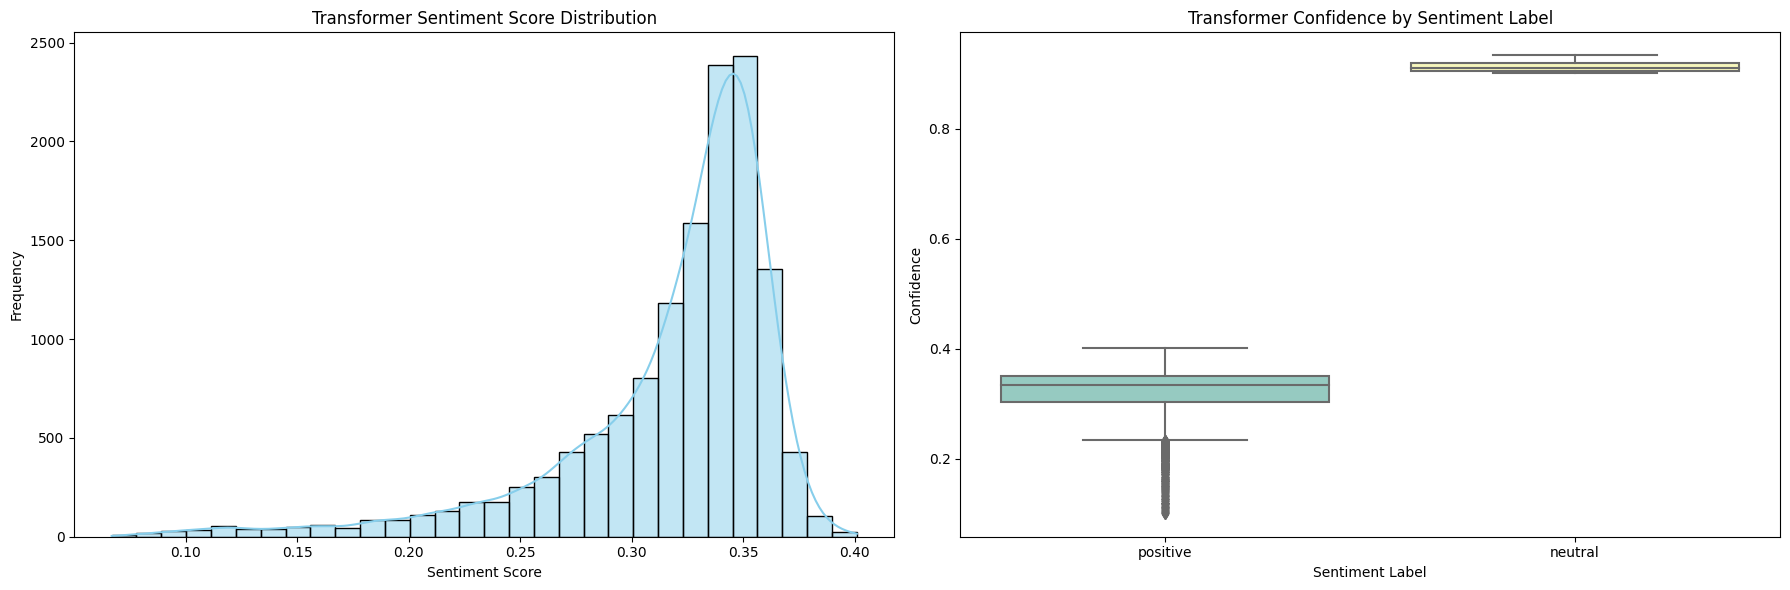

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# Define simplified plot grid
# ==============================
plt.figure(figsize=(18, 6))  # 1 row × 3 cols

# --------------------------------
# 1. Histogram: Transformer Sentiment Score
# --------------------------------
plt.subplot(1,2, 1)
sns.histplot(df['transformer_sentiment_score'], bins=30, kde=True, color='skyblue')
plt.title("Transformer Sentiment Score Distribution")
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")


# --------------------------------
# 3. Boxplot: Transformer Confidence by Sentiment Label
# --------------------------------
plt.subplot(1, 2, 2)
sns.boxplot(x='transformer_sentiment_label', y='transformer_confidence', data=df, palette='Set3')
plt.title("Transformer Confidence by Sentiment Label")
plt.xlabel("Sentiment Label")
plt.ylabel("Confidence")

# --------------------------------
plt.tight_layout()
plt.show()


# PHASE 7: EMOTION + SARCASM MODULE

In [18]:
import pandas as pd
import numpy as np
import emoji
import re
from collections import Counter

# ==============================
# PHASE 7: EMOTION + SARCASM MODULE
# ==============================

class EmotionSarcasmDetector:
    def __init__(self):
        # ============================================
        # EMOTION LEXICON (Enhanced)
        # ============================================
        self.emotion_lexicon = {
            'joy': {
                # English
                'happy', 'joy', 'joyful', 'delighted', 'pleased', 'cheerful', 
                'excited', 'thrilled', 'ecstatic', 'glad', 'satisfied', 'content',
                'wonderful', 'amazing', 'fantastic', 'great', 'excellent', 'love',
                'blessed', 'grateful', 'thankful', 'enjoy', 'fun', 'entertaining',
                
                # Roman Urdu
                'khush', 'khushi', 'mazay', 'maza', 'mast', 'shandar', 'behtreen',
                'dilchasp', 'mazedaar', 'acha', 'achha', 'kamaal', 'lajawaab'
            },
            
            'anger': {
                # English
                'angry', 'mad', 'furious', 'annoyed', 'irritated', 'frustrated',
                'outraged', 'enraged', 'upset', 'pissed', 'hate', 'disgusted',
                'irritating', 'annoying', 'infuriating', 'ridiculous', 'pathetic',
                'terrible', 'worst', 'horrible', 'awful', 'stupid', 'useless','shit',
                
                # Roman Urdu
                'gussa', 'ghussa', 'naraz', 'khafa', 'tang', 'pareshan',
                'pagal', 'bewakoof', 'bakwas', 'ghatiya', 'bekar', 'kharab'
            },
            
            'sadness': {
                # English
                'sad', 'unhappy', 'depressed', 'miserable', 'disappointed',
                'heartbroken', 'gloomy', 'down', 'blue', 'melancholy', 'sorrowful',
                'unfortunate', 'poor', 'sorry', 'regret', 'miss', 'lose', 'loss',
                
                # Roman Urdu
                'dukh', 'udaas', 'pareshan', 'mayoos', 'afsos', 'gham',
                'ronay', 'rona', 'takleef', 'musibat', 'mushkil'
            },
            
            'fear': {
                # English
                'afraid', 'scared', 'frightened', 'terrified', 'nervous',
                'worried', 'anxious', 'panic', 'horror', 'dread', 'alarmed',
                'concerned', 'uneasy', 'tense', 'stress', 'threat', 'danger',
                
                # Roman Urdu
                'dar', 'darr', 'khauf', 'ghabrana', 'ghabrahat', 'tension',
                'pareshan', 'fikr', 'chinta', 'khatre'
            },
            
            'surprise': {
                # English
                'surprised', 'shocked', 'amazed', 'astonished', 'stunned',
                'startled', 'wow', 'omg', 'unbelievable', 'incredible', 'unexpected',
                'sudden', 'amazing', 'whoa', 'wtf', 'seriously',
                
                # Roman Urdu
                'hairat', 'hairan', 'ajeeb', 'ajeeb', 'wah', 'kya', 'sach'
            }
        }
        
        # ============================================
        # EMOJI-BASED EMOTION MAPPING
        # ============================================
        self.emoji_emotion_map = {
            'joy': ['😊', '😃', '😄', '😁', '🥰', '😍', '🤗', '🎉', '🎊', '❤️', '💕', '💖', '👍', '👏', '✨', '⭐'],
            'anger': ['😠', '😡', '🤬', '💢', '👎', '🖕', '😤'],
            'sadness': ['😢', '😭', '😞', '😔', '💔', '😿', '😩'],
            'fear': ['😨', '😰', '😱', '🙀', '😧', '😦'],
            'surprise': ['😮', '😲', '🤯', '😳', '🙀', '‼️', '⁉️']
        }
        
        # ============================================
        # SARCASM DETECTION PATTERNS
        # ============================================
        self.sarcasm_patterns = {
            # Positive word + "but" + negative
            'praise_reversal': [
                r'(great|good|nice|excellent|amazing|wonderful|fantastic).*but.*(bad|terrible|awful|horrible|worst|poor)',
                r'(acha|achha|behtreen|kamaal).*but.*(bekar|ganda|kharab)'
            ],
            
            # Exaggerated praise
            'exaggeration': [
                r'wah\s+kya\s+baat',
                r'amazing.*not',
                r'best.*ever.*not',
                r'perfect.*totally',
                r'great\s+job.*fail'
            ],
            
            # Intensifier overload (too many intensifiers = sarcasm)
            'intensifier_spam': [
                r'(very|so|really|extremely|absolutely){3,}',
                r'(bohat|bahut|ziada){2,}'
            ],
            
            # Question + negative
            'rhetorical_negative': [
                r'why.*so.*bad',
                r'how.*this.*worst',
                r'what.*happened',
                r'kyun.*itna.*bekar'
            ]
        }
        
        # Sarcastic emoji combinations
        self.sarcasm_emojis = ['😂', '🤣', '😏', '🙄', '😒', '👎', '💩', '🤦', '🤷']
    
    # ============================================
    # EMOTION DETECTION
    # ============================================
    
    def detect_emotion_from_text(self, text):
        """
        Detect emotion from text using lexicon
        Returns: emotion_label, emotion_scores dict
        """
        if not text or pd.isna(text):
            return 'neutral', {}
        
        text = str(text).lower()
        words = set(text.split())
        
        emotion_scores = {}
        
        for emotion, emotion_words in self.emotion_lexicon.items():
            matches = words.intersection(emotion_words)
            emotion_scores[emotion] = len(matches)
        
        # Find dominant emotion
        if sum(emotion_scores.values()) == 0:
            return 'neutral', emotion_scores
        
        primary_emotion = max(emotion_scores, key=emotion_scores.get)
        
        return primary_emotion, emotion_scores
    
    def detect_emotion_from_emoji(self, text):
        """
        Detect emotion from emojis in text
        Returns: emotion_label, emoji_count dict
        """
        if not text or pd.isna(text):
            return 'neutral', {}
        
        text = str(text)
        
        # Extract all emojis
        text_emojis = [c for c in text if c in emoji.EMOJI_DATA]
        
        if not text_emojis:
            return 'neutral', {}
        
        # Count emotions from emojis
        emoji_emotion_scores = {emotion: 0 for emotion in self.emoji_emotion_map.keys()}
        
        for emoji_char in text_emojis:
            for emotion, emoji_list in self.emoji_emotion_map.items():
                if emoji_char in emoji_list:
                    emoji_emotion_scores[emotion] += 1
        
        # Find dominant emotion
        if sum(emoji_emotion_scores.values()) == 0:
            return 'neutral', emoji_emotion_scores
        
        primary_emotion = max(emoji_emotion_scores, key=emoji_emotion_scores.get)
        
        return primary_emotion, emoji_emotion_scores
    
    def detect_emotion_combined(self, text_preprocessed, text_original, transformer_sentiment=None):
        """
        Combine text lexicon + emoji + transformer for final emotion
        
        Parameters:
        -----------
        text_preprocessed : str
            Cleaned text
        text_original : str
            Original text with emojis
        transformer_sentiment : str
            Sentiment from transformer ('positive', 'negative', 'neutral')
        
        Returns:
        --------
        dict with emotion info
        """
        # Get text emotion
        text_emotion, text_scores = self.detect_emotion_from_text(text_preprocessed)
        
        # Get emoji emotion
        emoji_emotion, emoji_scores = self.detect_emotion_from_emoji(text_original)
        
        # Combine scores
        combined_scores = {}
        for emotion in self.emotion_lexicon.keys():
            combined_scores[emotion] = text_scores.get(emotion, 0) + emoji_scores.get(emotion, 0) * 2  # Weight emojis higher
        
        # Apply transformer sentiment as bias
        if transformer_sentiment:
            if transformer_sentiment == 'positive':
                combined_scores['joy'] += 2
            elif transformer_sentiment == 'negative':
                combined_scores['anger'] += 1
                combined_scores['sadness'] += 1
        
        # Final emotion
        if sum(combined_scores.values()) == 0:
            final_emotion = 'neutral'
        else:
            final_emotion = max(combined_scores, key=combined_scores.get)
        
        return {
            'emotion_final': final_emotion,
            'emotion_text': text_emotion,
            'emotion_emoji': emoji_emotion,
            'emotion_scores': combined_scores,
            'emotion_confidence': combined_scores.get(final_emotion, 0) / (sum(combined_scores.values()) + 1)
        }
    
    # ============================================
    # SARCASM DETECTION
    # ============================================
    
    def detect_sarcasm_patterns(self, text):
        """
        Detect sarcasm using pattern matching
        Returns: is_sarcasm, confidence, patterns_found
        """
        if not text or pd.isna(text):
            return False, 0.0, []
        
        text = str(text).lower()
        patterns_found = []
        sarcasm_score = 0.0
        
        # Check praise reversal
        for pattern in self.sarcasm_patterns['praise_reversal']:
            if re.search(pattern, text):
                sarcasm_score += 0.5
                patterns_found.append('praise_reversal')
        
        # Check exaggeration
        for pattern in self.sarcasm_patterns['exaggeration']:
            if re.search(pattern, text):
                sarcasm_score += 0.4
                patterns_found.append('exaggeration')
        
        # Check intensifier spam
        for pattern in self.sarcasm_patterns['intensifier_spam']:
            if re.search(pattern, text):
                sarcasm_score += 0.3
                patterns_found.append('intensifier_spam')
        
        # Check rhetorical questions
        for pattern in self.sarcasm_patterns['rhetorical_negative']:
            if re.search(pattern, text):
                sarcasm_score += 0.3
                patterns_found.append('rhetorical_negative')
        
        sarcasm_score = min(sarcasm_score, 1.0)
        is_sarcasm = sarcasm_score > 0.4
        
        return is_sarcasm, sarcasm_score, patterns_found
    
    def detect_sarcasm_emoji_mismatch(self, text_preprocessed, text_original, sentiment_polarity):
        """
        Detect sarcasm from emoji-sentiment mismatch
        
        Parameters:
        -----------
        text_preprocessed : str
            Cleaned text
        text_original : str
            Original text with emojis
        sentiment_polarity : float
            -1 to 1 sentiment score
        
        Returns:
        --------
        is_mismatch, mismatch_score
        """
        if not text_original or pd.isna(text_original):
            return False, 0.0
        
        text_original = str(text_original)
        
        # Check for sarcasm emojis
        has_sarcasm_emoji = any(e in text_original for e in self.sarcasm_emojis)
        
        # Check sentiment-emoji mismatch
        # Positive text + laughing/eye-roll emoji = sarcasm
        if sentiment_polarity > 0.3 and has_sarcasm_emoji:
            return True, 0.7
        
        return False, 0.0
    
    def detect_sarcasm_combined(self, text_preprocessed, text_original, sentiment_polarity):
        """
        Combined sarcasm detection
        
        Returns:
        --------
        dict with sarcasm info
        """
        # Pattern-based detection
        pattern_sarcasm, pattern_score, patterns = self.detect_sarcasm_patterns(text_preprocessed)
        
        # Emoji mismatch detection
        emoji_sarcasm, emoji_score = self.detect_sarcasm_emoji_mismatch(
            text_preprocessed, text_original, sentiment_polarity
        )
        
        # Combined score
        combined_score = max(pattern_score, emoji_score)
        
        # If either method detects sarcasm strongly, flag it
        is_sarcasm = combined_score > 0.4
        
        return {
            'sarcasm_detected': is_sarcasm,
            'sarcasm_confidence': combined_score,
            'sarcasm_patterns': patterns,
            'sarcasm_emoji_mismatch': emoji_sarcasm
        }


def apply_emotion_sarcasm_module(df):
    """
    Apply emotion and sarcasm detection to dataframe
    
    Parameters:
    -----------
    df : pd.DataFrame
        Must contain: text_preprocessed, text_original, 
                      lexicon_sentiment_polarity, transformer_sentiment_label
    
    Returns:
    --------
    df with emotion and sarcasm columns
    """
    
    print("🔄 Starting Phase 7: Emotion + Sarcasm Module...")
    
    detector = EmotionSarcasmDetector()
    
    results = []
    for idx, row in df.iterrows():
        if idx % 1000 == 0:
            print(f"   Processing: {idx}/{len(df)} reviews...")
        
        # Detect emotion
        emotion_result = detector.detect_emotion_combined(
            row.get('text_preprocessed', ''),
            row.get('text_original', ''),
            row.get('transformer_sentiment_label', None)
        )
        
        # Detect sarcasm
        sarcasm_result = detector.detect_sarcasm_combined(
            row.get('text_preprocessed', ''),
            row.get('text_original', ''),
            row.get('lexicon_sentiment_polarity', 0.0)
        )
        
        results.append({**emotion_result, **sarcasm_result})
    
    # Add columns
    df['emotion_final'] = [r['emotion_final'] for r in results]
    df['emotion_text'] = [r['emotion_text'] for r in results]
    df['emotion_emoji'] = [r['emotion_emoji'] for r in results]
    df['emotion_confidence'] = [r['emotion_confidence'] for r in results]
    
    df['sarcasm_detected'] = [r['sarcasm_detected'] for r in results]
    df['sarcasm_confidence'] = [r['sarcasm_confidence'] for r in results]
    df['sarcasm_emoji_mismatch'] = [r['sarcasm_emoji_mismatch'] for r in results]
    
    print("\n✅ Phase 7 Complete!")
    print(f"📊 Added emotion and sarcasm features")
    
    # Show distributions
    print("\n📊 Emotion Distribution:")
    print(df['emotion_final'].value_counts())
    
    print(f"\n📊 Sarcasm Detection Rate: {df['sarcasm_detected'].sum()} / {len(df)} ({df['sarcasm_detected'].mean()*100:.2f}%)")
    
    return df


# ==============================
# USAGE EXAMPLE
# ==============================

if __name__ == "__main__":
    
    print(f"📊 Total reviews: {len(df)}")
    
    # Apply emotion + sarcasm module
    df = apply_emotion_sarcasm_module(df)
    
    # Show samples
    print("\n📝 Sample Sarcastic Reviews:")
    sarcastic = df[df['sarcasm_detected'] == True].head(5)
    print(sarcastic[['text_original', 'emotion_final', 'sarcasm_confidence']])
    
    print("\n📝 Emotion Examples:")
    for emotion in ['joy', 'anger', 'sadness', 'fear', 'surprise']:
        sample = df[df['emotion_final'] == emotion].head(1)
        if not sample.empty:
            print(f"\n{emotion.upper()}: {sample['text_original'].values[0]}")

📊 Total reviews: 13559
🔄 Starting Phase 7: Emotion + Sarcasm Module...
   Processing: 0/13559 reviews...
   Processing: 1000/13559 reviews...
   Processing: 2000/13559 reviews...
   Processing: 3000/13559 reviews...
   Processing: 4000/13559 reviews...
   Processing: 5000/13559 reviews...
   Processing: 6000/13559 reviews...
   Processing: 7000/13559 reviews...
   Processing: 8000/13559 reviews...
   Processing: 9000/13559 reviews...
   Processing: 10000/13559 reviews...
   Processing: 11000/13559 reviews...
   Processing: 12000/13559 reviews...
   Processing: 13000/13559 reviews...

✅ Phase 7 Complete!
📊 Added emotion and sarcasm features

📊 Emotion Distribution:
emotion_final
joy         13353
anger          89
sadness        70
neutral        46
surprise        1
Name: count, dtype: int64

📊 Sarcasm Detection Rate: 19 / 13559 (0.14%)

📝 Sample Sarcastic Reviews:
                                          text_original emotion_final  \
734   what's app It was good before, now it's bad

/tmp/ipykernel_20/1138235020.py:381: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['emotion_final'] = [r['emotion_final'] for r in results]
/tmp/ipykernel_20/1138235020.py:382: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['emotion_text'] = [r['emotion_text'] for r in results]
/tmp/ipykernel_20/1138235020.py:383: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http

## Phase 7 Ploting

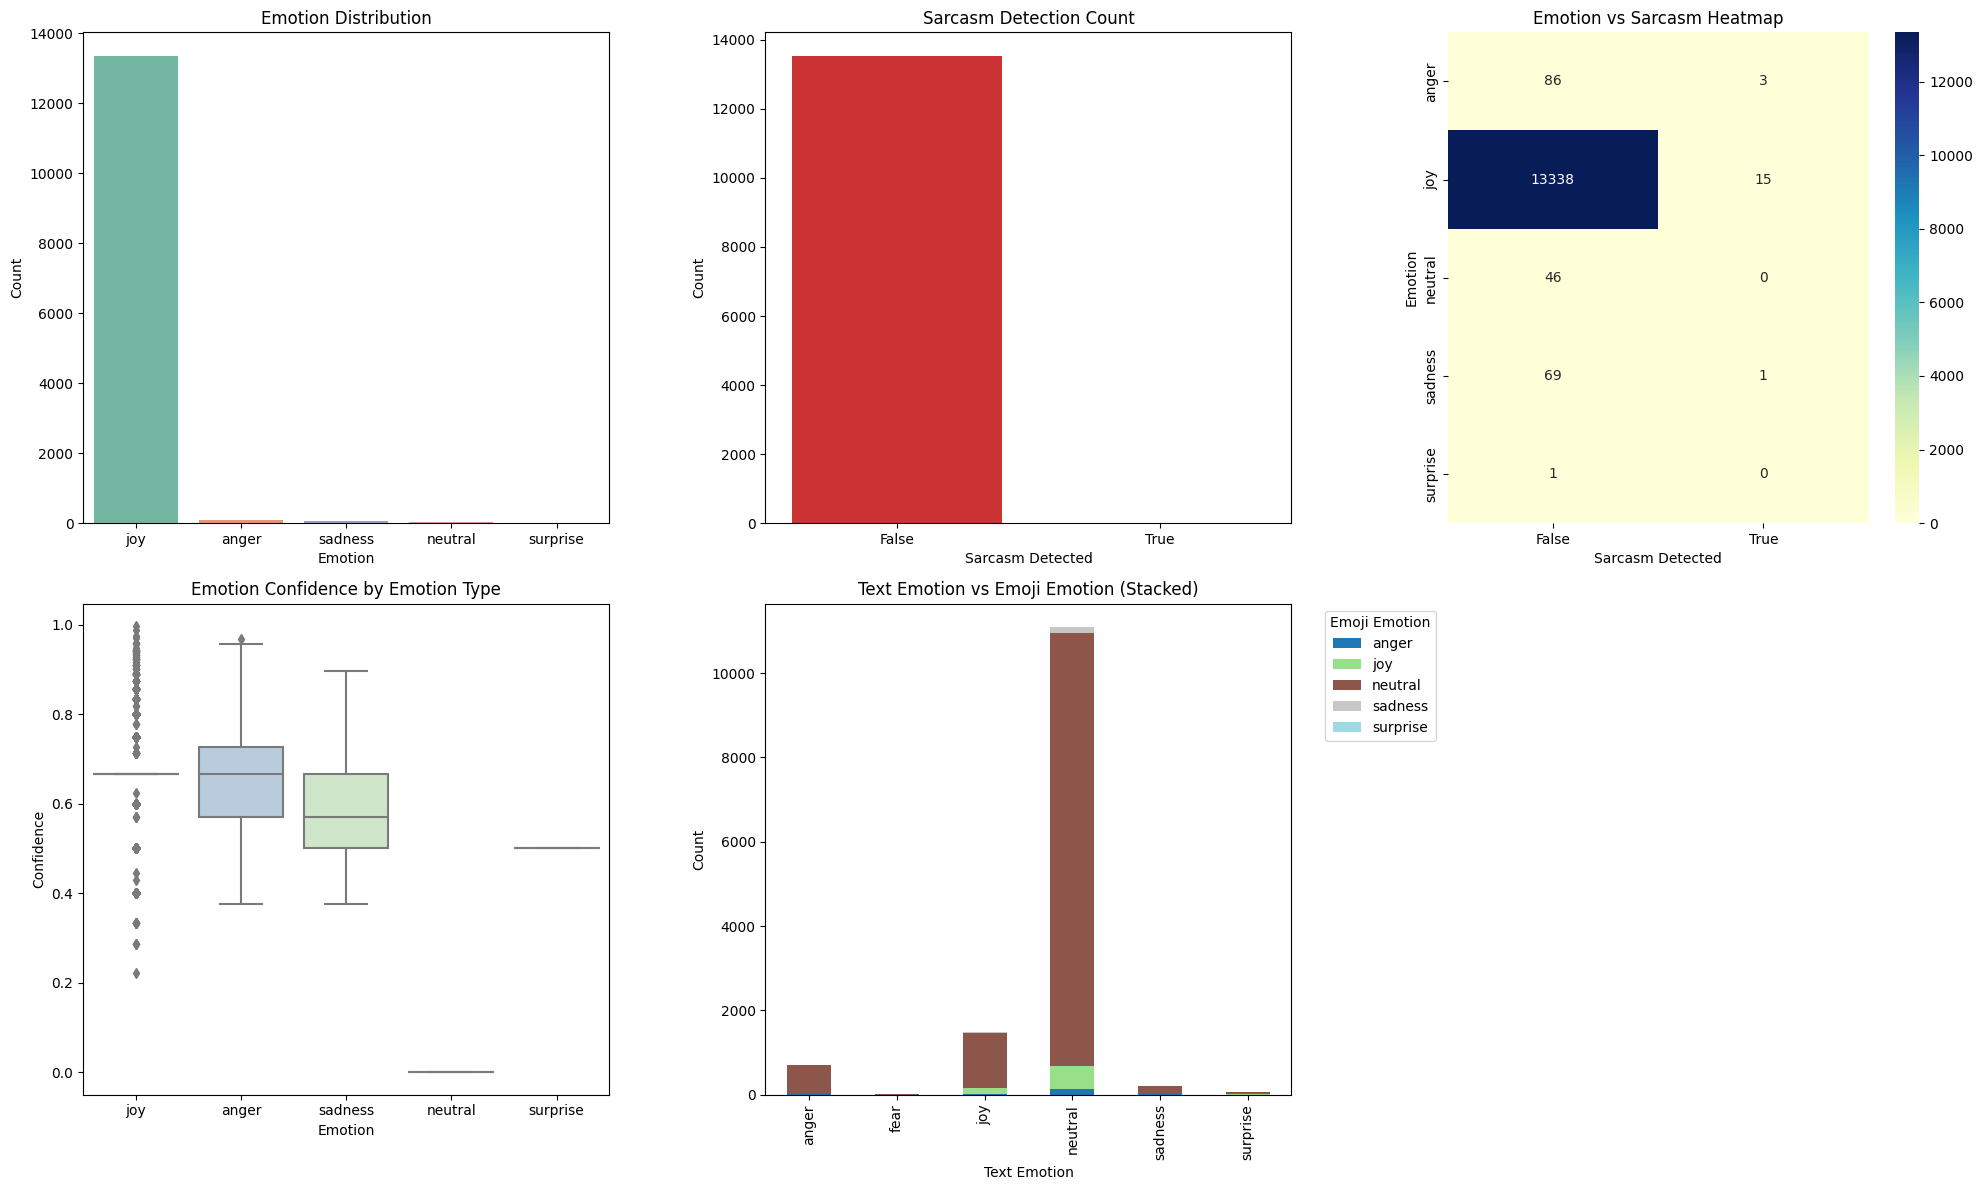

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==============================
# Load Phase 7 dataset
# ==============================
# Setup figure
# ==============================
plt.figure(figsize=(20, 12))

# --------------------------------
# 1. Emotion Distribution
# --------------------------------
plt.subplot(2, 3, 1)
sns.countplot(x='emotion_final', data=df, palette='Set2', order=df['emotion_final'].value_counts().index)
plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")

# --------------------------------
# 2. Sarcasm Detection Count
# --------------------------------
plt.subplot(2, 3, 2)
sns.countplot(x='sarcasm_detected', data=df, palette='Set1')
plt.title("Sarcasm Detection Count")
plt.xlabel("Sarcasm Detected")
plt.ylabel("Count")

# --------------------------------
# 3. Heatmap: Emotion vs Sarcasm
# --------------------------------
plt.subplot(2, 3, 3)
emotion_sarcasm = pd.crosstab(df['emotion_final'], df['sarcasm_detected'])
sns.heatmap(emotion_sarcasm, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Emotion vs Sarcasm Heatmap")
plt.xlabel("Sarcasm Detected")
plt.ylabel("Emotion")

# --------------------------------
# 4. Emotion Confidence Boxplot
# --------------------------------
plt.subplot(2, 3, 4)
sns.boxplot(x='emotion_final', y='emotion_confidence', data=df, palette='Pastel1')
plt.title("Emotion Confidence by Emotion Type")
plt.xlabel("Emotion")
plt.ylabel("Confidence")

# --------------------------------
# 5. Emoji vs Text Emotion Comparison (stacked bar)
# --------------------------------
plt.subplot(2, 3, 5)
emoji_vs_text = pd.crosstab(df['emotion_text'], df['emotion_emoji'])
emoji_vs_text.plot(kind='bar', stacked=True, ax=plt.gca(), colormap='tab20')
plt.title("Text Emotion vs Emoji Emotion (Stacked)")
plt.xlabel("Text Emotion")
plt.ylabel("Count")
plt.legend(title="Emoji Emotion", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


# PHASE 8: FINAL SENTIMENT ANALYSIS LAYER

In [20]:
import pandas as pd
import numpy as np
import pickle

# ==============================
# PHASE 8: BALANCED SENTIMENT ANALYSIS LAYER
# ==============================

class FinalSentimentAnalyzer:
    def __init__(self):
        """
        Initialize Final Sentiment Analyzer
        Real-world balanced scoring system
        """
        print("✅ Final Sentiment Analyzer Initialized (Balanced Mode)")
    
    def determine_sentiment_label(self, transformer_score, lexicon_score, 
                                   sarcasm_detected, emotion, rating):
        """
        Real-world balanced sentiment scoring
        
        Parameters:
        -----------
        transformer_score : float
            Transformer sentiment score (-1 to 1)
        lexicon_score : float
            Lexicon sentiment polarity (-1 to 1)
        sarcasm_detected : bool
            Whether sarcasm is detected
        emotion : str
            Detected emotion
        rating : int
            User rating (1-5)
        
        Returns:
        --------
        sentiment_label : str
        combined_score : float
        """
        # Apply sarcasm reversal
        if sarcasm_detected:
            transformer_score = -transformer_score
            lexicon_score = -lexicon_score
        
        # Weighted combination (more balanced)
        combined_score = (
            0.40 * transformer_score +  # Transformer weight
            0.30 * lexicon_score +       # Lexicon weight
            0.30 * self._rating_to_sentiment(rating)  # Rating weight
        )
        
        # Emotion-based adjustment (refined)
        if emotion == 'joy':
            combined_score += 0.15
        elif emotion == 'anger':
            combined_score -= 0.20
        elif emotion == 'sadness':
            combined_score -= 0.15
        elif emotion == 'fear':
            combined_score -= 0.10
        elif emotion == 'surprise':
            combined_score += 0.05
        
        # Clip to [-1, 1]
        combined_score = np.clip(combined_score, -1, 1)
        
        # Real-world classification thresholds (more balanced)
        if combined_score >= 0.25:
            return 'positive', combined_score
        elif combined_score >= 0.1:
            return 'neutral', combined_score
        else:
            return 'negative', combined_score
    
    def _rating_to_sentiment(self, rating):
        """
        Convert rating (1-5) to sentiment score (-1 to 1)
        """
        if pd.isna(rating):
            return 0.0
        
        rating = float(rating)
        
        # Real-world mapping
        if rating >=4:
            return 0.5
        elif rating >=3:
            return 0.0
        else:
            return -0.5
    
    def calculate_sentiment_confidence(self, combined_score, transformer_confidence,
                                       lexicon_confidence, sarcasm_confidence):
        """
        Calculate confidence with better calibration
        """
        # Distance from neutral (stronger signal = higher confidence)
        score_confidence = min(abs(combined_score) * 1.5, 1.0)
        
        # Component confidences
        avg_confidence = (transformer_confidence + lexicon_confidence) / 2
        
        # Sarcasm penalty (reduced)
        sarcasm_penalty = 1.0 - (sarcasm_confidence * 0.2)
        
        # Combined confidence
        final_confidence = score_confidence * avg_confidence * sarcasm_penalty
        
        return np.clip(final_confidence, 0.0, 1.0)
    
    def apply_lexicon_boost_adjustment(self, base_sentiment, lexicon_adjusted_sentiment):
        """
        Moderate lexicon boost (reduced from original)
        """
        boost_factor = abs(lexicon_adjusted_sentiment - base_sentiment)
        
        if boost_factor > 0.3:
            # Strong signal - 30% boost (reduced from 50%)
            boosted = base_sentiment + 0.3 * (lexicon_adjusted_sentiment - base_sentiment)
        else:
            # Weak signal - 10% boost (reduced from 20%)
            boosted = base_sentiment + 0.1 * (lexicon_adjusted_sentiment - base_sentiment)
        
        return np.clip(boosted, -1, 1)
    
    def analyze_sentiment(self, row):
        """
        Complete sentiment analysis with balanced scoring
        """
        # Extract features
        transformer_score = row.get('transformer_sentiment_score', 0.0)
        transformer_confidence = row.get('transformer_confidence', 0.5)
        lexicon_polarity = row.get('lexicon_sentiment_polarity', 0.0)
        lexicon_adjusted = row.get('lexicon_sentiment_adjusted', 0.0)
        sarcasm_detected = row.get('sarcasm_detected', False)
        sarcasm_confidence = row.get('sarcasm_confidence', 0.0)
        emotion = row.get('emotion_final', 'neutral')
        rating = row.get('rating', 3.0)
        
        # Determine final sentiment
        sentiment_label, combined_score = self.determine_sentiment_label(
            transformer_score,
            lexicon_polarity,
            sarcasm_detected,
            emotion,
            rating
        )
        
        # Calculate confidence
        lexicon_confidence = min(abs(lexicon_polarity) * 1.5, 1.0)
        confidence = self.calculate_sentiment_confidence(
            combined_score,
            transformer_confidence,
            lexicon_confidence,
            sarcasm_confidence
        )
        
        # Apply moderate lexicon boost
        sentiment_after_boost = self.apply_lexicon_boost_adjustment(
            combined_score,
            lexicon_adjusted
        )
        
        # Re-classify after boost (same thresholds)
        if sentiment_after_boost >= 0.25:
            sentiment_label_boosted = 'positive'
        elif sentiment_after_boost >= 0.12:
            sentiment_label_boosted = 'neutral'
        else:
            sentiment_label_boosted = 'negative'
        
        return {
            'sentiment_final': sentiment_label_boosted,
            'sentiment_score': sentiment_after_boost,
            'sentiment_confidence': confidence,
            'sentiment_emotion': emotion,
            'sentiment_sarcasm_applied': sarcasm_detected,
            'sentiment_before_boost': combined_score,
            'sentiment_after_boost': sentiment_after_boost
        }


def apply_final_sentiment_analysis(df):
    """
    Apply balanced sentiment analysis layer
    """
    print("🔄 Starting Phase 8: Balanced Sentiment Analysis...")
    
    analyzer = FinalSentimentAnalyzer()
    
    results = []
    for idx, row in df.iterrows():
        if idx % 1000 == 0:
            print(f"   Processing: {idx}/{len(df)} reviews...")
        
        result = analyzer.analyze_sentiment(row)
        results.append(result)
    
    # Add columns
    df['sentiment_final'] = [r['sentiment_final'] for r in results]
    df['sentiment_score'] = [r['sentiment_score'] for r in results]
    df['sentiment_confidence'] = [r['sentiment_confidence'] for r in results]
    df['sentiment_emotion'] = [r['sentiment_emotion'] for r in results]
    df['sentiment_sarcasm_applied'] = [r['sentiment_sarcasm_applied'] for r in results]
    df['sentiment_before_boost'] = [r['sentiment_before_boost'] for r in results]
    df['sentiment_after_boost'] = [r['sentiment_after_boost'] for r in results]
    
    print("\n✅ Phase 8 Complete!")
    print(f"📊 Added sentiment features with balanced scoring")
    
    # Show distributions
    print("\n📊 Final Sentiment Distribution (Balanced):")
    sentiment_dist = df['sentiment_final'].value_counts()
    for sentiment, count in sentiment_dist.items():
        pct = (count / len(df)) * 100
        print(f"   {sentiment}: {count} ({pct:.2f}%)")
    
    print(f"\n📊 Sarcasm Applied: {df['sentiment_sarcasm_applied'].sum()} ({df['sentiment_sarcasm_applied'].mean()*100:.2f}%)")
    
    print(f"\n📊 Sentiment Score Statistics:")
    print(df['sentiment_score'].describe())
    
    print(f"\n📊 Sentiment-Emotion Cross-tabulation:")
    crosstab = pd.crosstab(df['sentiment_final'], df['sentiment_emotion'])
    print(crosstab)
    
    return df


def generate_sentiment_summary(df):
    """
    Generate comprehensive summary
    """
    summary = {
        'total_reviews': len(df),
        'sentiment_distribution': df['sentiment_final'].value_counts().to_dict(),
        'avg_sentiment_score': df['sentiment_score'].mean(),
        'avg_confidence': df['sentiment_confidence'].mean(),
        'sarcasm_rate': df['sentiment_sarcasm_applied'].mean(),
        'emotion_distribution': df['sentiment_emotion'].value_counts().to_dict(),
        'positive_reviews_pct': (df['sentiment_final'] == 'positive').mean() * 100,
        'negative_reviews_pct': (df['sentiment_final'] == 'negative').mean() * 100,
        'neutral_reviews_pct': (df['sentiment_final'] == 'neutral').mean() * 100,
    }
    
    if 'app_name' in df.columns:
        summary['sentiment_by_app'] = df.groupby('app_name')['sentiment_final'].value_counts().to_dict()
    
    if 'rating' in df.columns:
        summary['sentiment_by_rating'] = df.groupby('rating')['sentiment_final'].value_counts().to_dict()
    
    return summary


# ==============================
# USAGE
# ==============================
if __name__ == "__main__":
    print(f"📊 Total reviews: {len(df)}")
    
    # Apply balanced sentiment analysis
    df = apply_final_sentiment_analysis(df)
    
    # Save
    df.to_csv('dataset_final_sentiment_balanced.csv', index=False)
    print(f"\n✅ Dataset saved: dataset_final_sentiment_balanced.csv")
    
    # Generate summary
    print("\n📊 Generating Summary...")
    summary = generate_sentiment_summary(df)
    
    print(f"\n📊 Overall Summary (Balanced Scoring):")
    print(f"   Total Reviews: {summary['total_reviews']}")
    print(f"   Positive: {summary['positive_reviews_pct']:.2f}%")
    print(f"   Negative: {summary['negative_reviews_pct']:.2f}%")
    print(f"   Neutral: {summary['neutral_reviews_pct']:.2f}%")
    print(f"   Avg Score: {summary['avg_sentiment_score']:.3f}")
    print(f"   Avg Confidence: {summary['avg_confidence']:.3f}")
    print(f"   Sarcasm Rate: {summary['sarcasm_rate']*100:.2f}%")
    
    # Save summary
    with open('sentiment_summary_balanced.pkl', 'wb') as f:
        pickle.dump(summary, f)
    print(f"✅ Summary saved: sentiment_summary_balanced.pkl")
    
    # Show samples
    print("\n📝 Sample Results:")
    print(df[['text_original', 'sentiment_final', 'sentiment_score', 
              'sentiment_confidence', 'rating']].head(10))

📊 Total reviews: 13559
🔄 Starting Phase 8: Balanced Sentiment Analysis...
✅ Final Sentiment Analyzer Initialized (Balanced Mode)
   Processing: 0/13559 reviews...
   Processing: 1000/13559 reviews...
   Processing: 2000/13559 reviews...
   Processing: 3000/13559 reviews...
   Processing: 4000/13559 reviews...
   Processing: 5000/13559 reviews...
   Processing: 6000/13559 reviews...
   Processing: 7000/13559 reviews...
   Processing: 8000/13559 reviews...
   Processing: 9000/13559 reviews...
   Processing: 10000/13559 reviews...
   Processing: 11000/13559 reviews...
   Processing: 12000/13559 reviews...
   Processing: 13000/13559 reviews...

✅ Phase 8 Complete!
📊 Added sentiment features with balanced scoring

📊 Final Sentiment Distribution (Balanced):
   positive: 6955 (51.29%)
   negative: 4201 (30.98%)
   neutral: 2403 (17.72%)

📊 Sarcasm Applied: 19 (0.14%)

📊 Sentiment Score Statistics:
count    13559.000000
mean         0.253042
std          0.192366
min         -0.558813
25%     

## Phase 8 Ploting

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


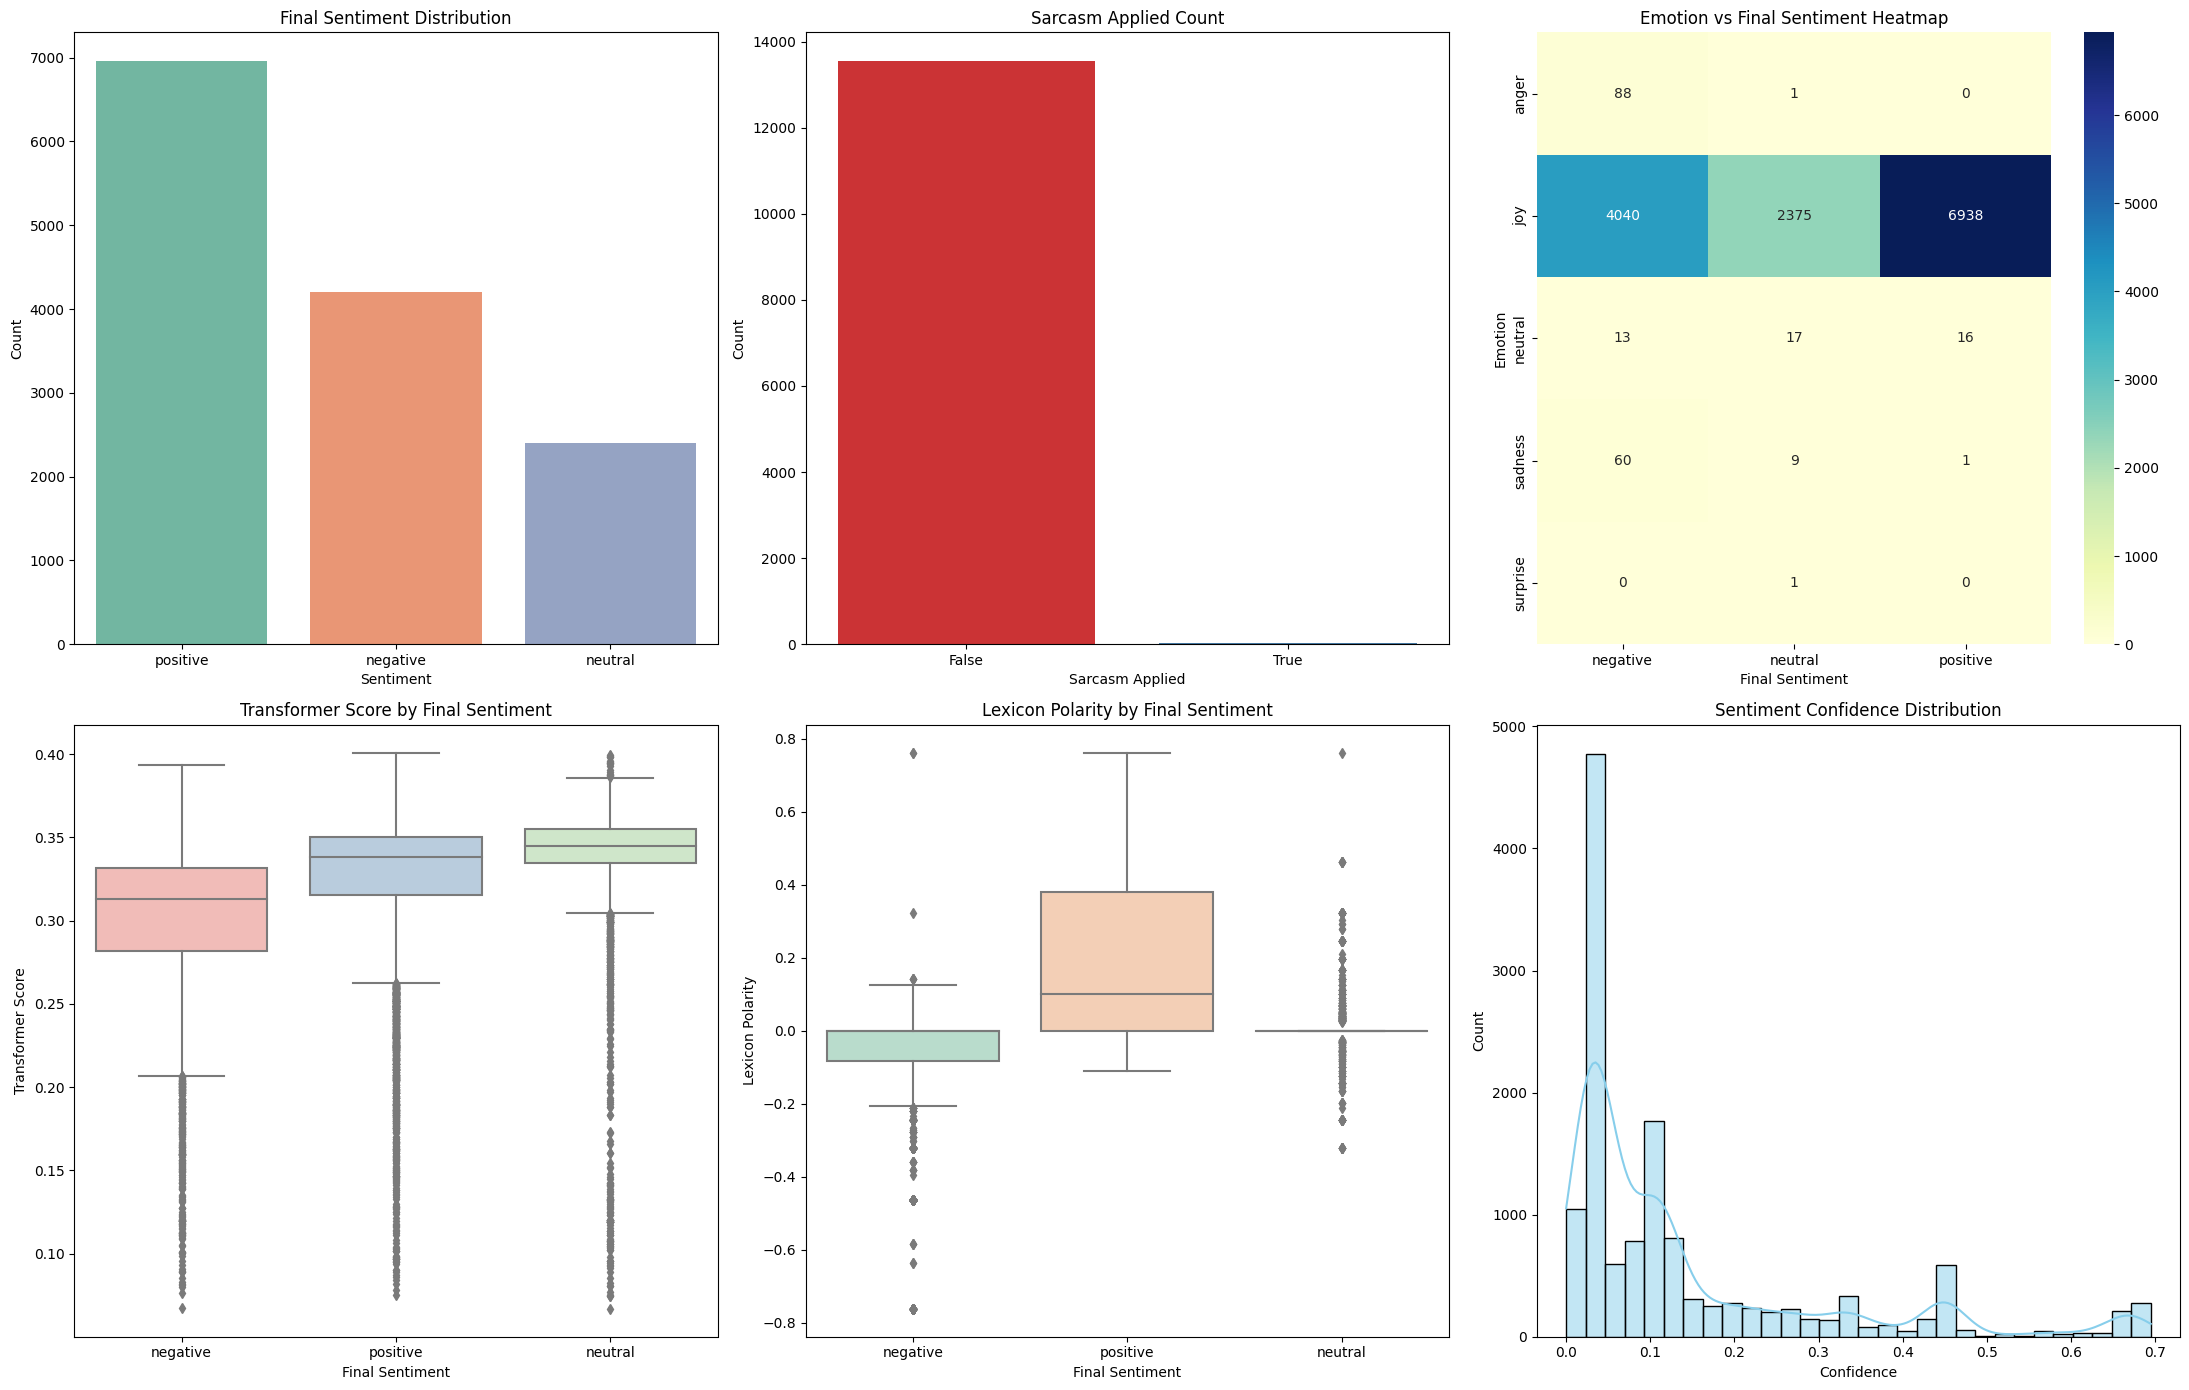

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


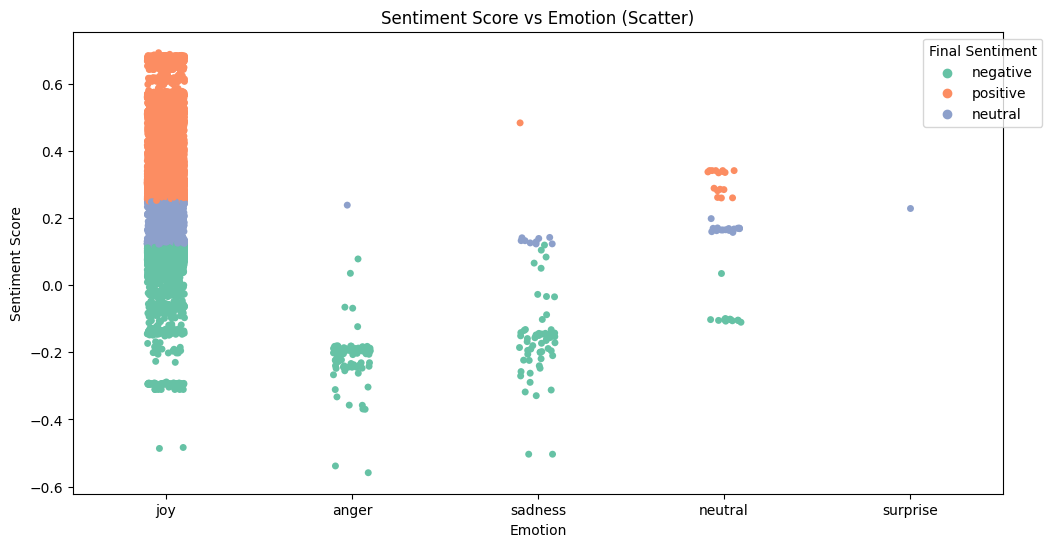

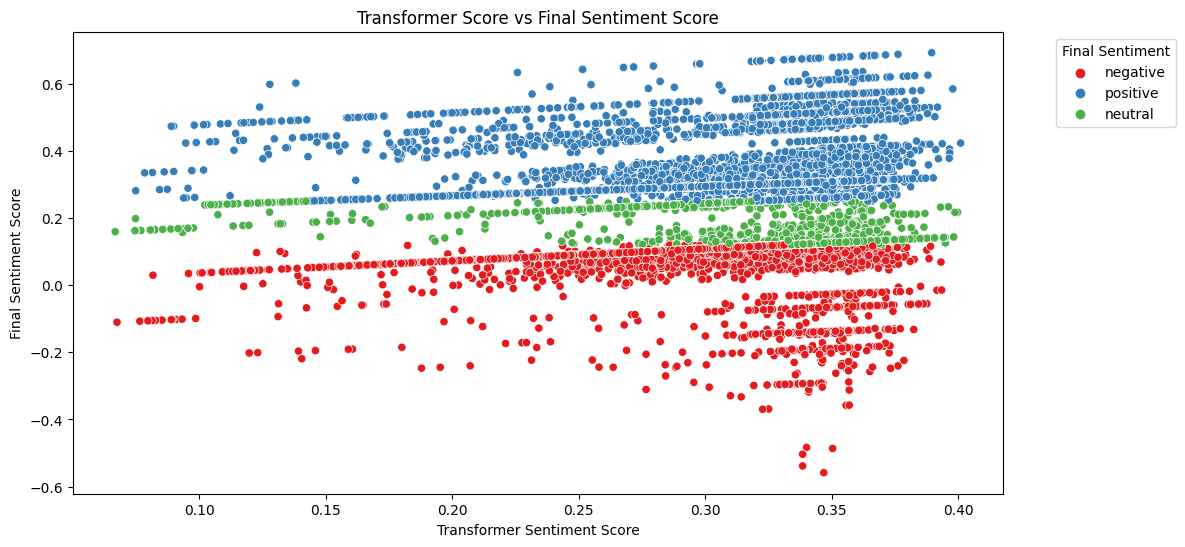

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==============================

plt.figure(figsize=(22, 14))

# -----------------------------
# 1. Final Sentiment Distribution
# -----------------------------
plt.subplot(2, 3, 1)
sns.countplot(x='sentiment_final', data=df, palette='Set2',
              order=df['sentiment_final'].value_counts().index)
plt.title("Final Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

# -----------------------------
# 2. Sarcasm Applied Count
# -----------------------------
plt.subplot(2, 3, 2)
sns.countplot(x='sentiment_sarcasm_applied', data=df, palette='Set1')
plt.title("Sarcasm Applied Count")
plt.xlabel("Sarcasm Applied")
plt.ylabel("Count")

# -----------------------------
# 3. Emotion vs Final Sentiment Heatmap
# -----------------------------
plt.subplot(2, 3, 3)
emotion_sentiment = pd.crosstab(df['sentiment_emotion'], df['sentiment_final'])
sns.heatmap(emotion_sentiment, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Emotion vs Final Sentiment Heatmap")
plt.xlabel("Final Sentiment")
plt.ylabel("Emotion")

# -----------------------------
# 4. Transformer Score vs Final Sentiment (Boxplot)
# -----------------------------
plt.subplot(2, 3, 4)
sns.boxplot(x='sentiment_final', y='transformer_sentiment_score', data=df, palette='Pastel1')
plt.title("Transformer Score by Final Sentiment")
plt.xlabel("Final Sentiment")
plt.ylabel("Transformer Score")

# -----------------------------
# 5. Lexicon Polarity vs Final Sentiment (Boxplot)
# -----------------------------
plt.subplot(2, 3, 5)
sns.boxplot(x='sentiment_final', y='lexicon_sentiment_polarity', data=df, palette='Pastel2')
plt.title("Lexicon Polarity by Final Sentiment")
plt.xlabel("Final Sentiment")
plt.ylabel("Lexicon Polarity")

# -----------------------------
# 6. Sentiment Confidence Distribution
# -----------------------------
plt.subplot(2, 3, 6)
sns.histplot(df['sentiment_confidence'], bins=30, kde=True, color='skyblue')
plt.title("Sentiment Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


# -----------------------------
# 7. Sentiment Score vs Emotion (Scatter)
# -----------------------------
plt.figure(figsize=(12, 6))
sns.stripplot(x='sentiment_emotion', y='sentiment_score', hue='sentiment_final', data=df, jitter=True, palette='Set2')
plt.title("Sentiment Score vs Emotion (Scatter)")
plt.xlabel("Emotion")
plt.ylabel("Sentiment Score")
plt.legend(title='Final Sentiment', bbox_to_anchor=(1.05, 1))
plt.show()


# -----------------------------
# 8. Optional: Transformer vs Final Score Comparison
# -----------------------------
plt.figure(figsize=(12, 6))
sns.scatterplot(x='transformer_sentiment_score', y='sentiment_score', hue='sentiment_final', data=df, palette='Set1')
plt.title("Transformer Score vs Final Sentiment Score")
plt.xlabel("Transformer Sentiment Score")
plt.ylabel("Final Sentiment Score")
plt.legend(title='Final Sentiment', bbox_to_anchor=(1.05, 1))
plt.show()
